# Project 03: How Uranium Sample Geometry Affects the Propogation of Fission within the Sample
**Name:** Alex Keightley <br>
**Student Number:** 76258516

# Introduction

In this project we will examine how the geometry of Uranium-235 samples affects the propagation of nuclear fission. We will model a simplified fission process and observe how changing the ratio of fuel sample shape dimensions and changing the sample volume impact the fission multiplication factor $k$; the ratio of thermal neutrons from generation to generation. This will be accomplished through phase space analyses on how changing the ratios of shape dimensions — the shape aspect ratio (SAR) — at a constant volume and how changing the volume at a constant SAR influence the $k$ factor. In general the SAR will be determined as a ratio of the shapes longer dimension to its shorter and the specifics of our working definition will be explicitly defined in the *Geometry* section of the report.

The first phase space analysis will examine how changing SAR affects $k$; we will simulate both rectangular prism fuel samples as well as cylindrical fuel samples and vary the SAR over values from $1\to10$, observing the mean multiplication factor $\bar{k}$ across an number of trials. Following this, we will then simulate rectangular prism, spherical, cylindrical and cube-shaped fuel samples across a range of volumes, again observing $\bar{k}$.

This python simulation is a simplified model for fission chain reaction of Uranium-235 $\left(^{235}U\right)$ as described by Enrico Fermi in the Chicago in the 1940s. It will use Monte Carlo techniques to perform an analysis of how different input conditions affect the propagation of fission events within a $^{235}U$ sample. Some of the assumptions that we are working with include:

>1. we will be using 100\% pure $^{235}U$ samples with the assumption that although the magnitude of the multiplication factor will differ using fuel of lesser purity, the behaviour and trends observed will be similar
>2. the neutron multiplicity $^{[3]}$ (mean number of neutrons produced by each fission event) of $^{235}U = 2.4355^{[1]}$.
>3. anywhere from $0\to N$ for $N\in\mathbb{N}$ neutrons will be produced by each fission event with a mean value set the the neutron multiplicity
>4. neutrons produced by all fission events are thermal neutrons
>5. neutrons exiting the fuel sample are lost to the system
>6. fuel sample shapes include: cube; sphere; prism; and cylinder

We note that some of these assumptions are simplifying assumptions for the purposes of producing a simplified fission reaction model. One of these simplifications is our use of a Poisson distribution with a mean set to the neutron multiplicity in order to generate the number of neutrons produced for each thermal neutron undergoing fission, as this can produce values in excess of the $2$ to $3$ neutrons produced each $^{235}U$ fission event $^{[2]}$. Another is the consideration of only thermal neutrons. The limitations of these assumptions and their departure from actual observations will be highlighted within the conclusion of this report.

We will analyze how changes to SAR and volume affect the multiplication factor across multiple generations and observe whether there is any correlation between the geometry of the fuel sample and fission propagation. A metric we will be observing across both explorations is whether changes in surface area to volume ratio correspond with changes in the $k$ factor. Though not a parameter we are changing directly, by running models with variances in either SAR or volume, we will observe changes in the samples surface area to volume ratio; we expect to observe changes in the behaviour of the multiplication factor as well. We will also be observing the general trends in $k$ factors across generations for specific shapes, volumes and SARs, where we are interested whether the $k$ factor tends towards steady-state stability, experiences growth, or tends towards zero.

## Background

We have traveled back in time to Chicago 1942, to the office of Enrico Fermi, and have written a python simulation of a simplified Uranium-235 fission model in order to help his investigation into the physics of Uranium fission via thermal neutrons. We have decided to explore how Uranium fuel sample shape affects the fission multiplication factor $k$; particularly, we will be exploring how sample volume and SAR affect the propagation of fission.

With fission we will be interested in the multiplication factor, $k$, where we define the multiplication factor as:
$$
\begin{align}
    \text{Multiplication factor, } k &= \frac{N_{n+1}}{N_n}
\end{align}
$$
where $N_n$ is the number of neutrons produced in generation $n$ of the fission process $^{[1]}$. From this we will define the reaction as sub-critical, critical or supercritical as follows $^{[1]}$:
$$
\begin{align}
    \text{Subcritical}: &&k < 1 \\
    \text{Critical}: &&k = 1 \\
    \text{Supercritical}: && k > 1
\end{align}
$$
With subcritical reactions we would expect the reaction process to eventually halt as there are not enough produced thermal neutrons to drive further fission reactions $^{[1]}$. Critical reactions would produce a self-sustaining reaction process in which the number of neutrons produced that remain within the sample are just enough to continue driving a reaction $^{[1]}$. Finally, supercritical reactions are ones in which the reaction process is expected to increase exponentially $^{[1]}$. Although this would typically be of concern for use in power-generating reactors, we note that due to the time-period we have arrived in the research of supercritical reactions would allow the Western allies to get a significant lead on the Axis powers in the development of a Nuclear bomb; whether that is a good thing remains for us to see upon our return to our own timeline.

We start with a specified number of thermal neutrons within the fuel sample $N_0$. Each neutron will then move a random distance $d$ in a random direction where the distances are randomly generated via an exponential distribution described by
$$
\begin{align}
    p(d) \propto e^{\left(-\frac{d}{\lambda}\right)}
\end{align}
$$
for mean free path length $\lambda^{[1]}$. We define the mean free path length as the average distance a thermal neutron will travel within the specified material ($^{235}U$ in this case) before being captured by a nucleus $^{[1]}$. Fermi has provided us with an estimated mean free path for $^{235}U$ of $\lambda = 0.15 \text{ m}^{[1]}$. He has also provided an estimated neutron multiplicity for $^{235}U$ of $2.4355^{[1]}$.

With these parameters, we will begin our exploration of our chose phase-spaces.

## Geometry

Our analysis across both phase spaces involves an exploration on how geometry affects the fission multiplication factor. We expect that there will be a relationship between the surface area to volume ratio and the multiplication factor. We further expect this relationship to be inversely proportional, where increases in the ratio will correlate with decreases in the multiplication factor. This expectation is guided by the reasoning that with more surface area to interact with per unit volume there will be a greater likelihood that the randomly generated directions for neutrons will cause the neutrons to cross the sample barrier and be removed from the system. We also that the volume of a sample held at a constant SAR will be positively correlated with the $k$ factor; if there are further distances to travel within a shape before crossing the barrier whilst the mean free path distance has remained constant we reason that there will be more neutrons retained within the sample over time.

Below we have included some relevant geometric formula from which our expectations and predictions have been guided. We have included formulae for volume, SAR (where we have assumed the prism is a rectangular prism such that $l=w$), surface area, and surface area to volume ratio. We have further calculated the surface area to volume ratio for a unit volume $V=1\text{ m}^3$ for each shape, where for the cylinder and rectangular prism we have set the SAR to $2$. In doing this we can further inform our expectations regarding which fuel sample shapes we expect to have higher $k$ factors within each phase-space analysis.


**Volume Formulae**
$$
\begin{align}
    \text{Volume of a Sphere, } V_\text{sphere} &= \frac{4}{3}\pi r^3\\
    \text{Volume of a Cylinder, } V_\text{cylinder} &= \pi r^2 h\\
    \text{Volume of a Cube, } V_\text{cube} &= l^3\\
    \text{Volume of a Rectangular Prism, } V_\text{prism} &= l w h
\end{align}
$$

**Shape Aspect Ratio Formulae**
$$
\begin{align}
    \text{Shape Aspect Ratio of a Sphere, } V_\text{sphere} &= \frac{r}{r} \\
    \text{Shape Aspect Ratio of a Cylinder, } V_\text{cylinder} &= \frac{h}{r} \\
    \text{Shape Aspect Ratio of a Cube, } V_\text{cube} &= \frac{l}{l}\\
    \text{Shape Aspect Ratio of a Rectangular Prism, } V_\text{prism} &= \frac{h}{l} 
\end{align}
$$

**Surface Area Formulae**
$$
\begin{align}
    \text{Surface Area of a Sphere, } V_\text{sphere} &= 4\pi r^2\\
    \text{Surface Area of a Cylinder, } V_\text{cylinder} &= 2\pi r^2 + 2\pi rh \\
    \text{Surface Area of a Cube, } V_\text{cube} &= 6l^2\\
    \text{Surface Area of a Prism, } V_\text{prism} &= 2(lw + lh + wh)
\end{align}
$$

**Surface Area to Volume Ratio Formulae**
$$
\begin{align}
    \text{Surface Area to Volume Ratio of a Sphere, } SA:V_\text{sphere} &= \frac{3}{r}\\
    \text{Surface Area to Volume Ratio of a Cylinder, } SA:V_\text{cylinder} &= \frac{2(r+h)}{rh} \\
    \text{Surface Area to Volume Ratio of a Cube, } SA:V_\text{cube} &= \frac{6}{l}\\
    \text{Surface Area to Volume Ratio of a Rectangular Prism, } SA:V_\text{prism} &= 2\left(\frac{1}{l} + \frac{1}{w} + \frac{1}{h}\right)
\end{align}
$$

Now we will proceed by calcalating the surface area to volume ratio for each of the shapes for unit volume $V=1\text{ m}^3$ and we will further assume a SAR of $2$ for both the rectangular prism and cylinder.

**Surface Area to Volume Ratio per Unit Volume for Each Sample Shape**
$$
\begin{align}
    \text{Surface Area to Volume for Unit Volume of Sphere } V &= \frac{3}{\sqrt[3]{\frac{3}{4\pi}}} \text{ m}^{-1} \\
    &\approx 4.84 \text{ m}^{-1}\\\\
    \text{Surface Area to Volume for Unit Volume of Cylinder } V &= \frac{3}{\sqrt[3]{\frac{1}{2\pi}}} \text{ m}^{-1} \\
    &\approx 5.54 \text{ m}^{-1}\\\\
    \text{Surface Area to Volume for Unit Volume of Cube } V &= 6 \text{ m}^{-1}\\\\
    \text{Surface Area to Volume for Unit Volume of Rectangular Prism } V &= \frac{5}{\sqrt[3]{\frac{1}{2}}} \text{ m}^{-1} \\
    &\approx 6.30 \text{ m}^{-1}
\end{align}
$$

From this we can see that for surface area to volume ratio for unit volume we have $\text{sphere} < \text{cylinder} < \text{cube} < \text{rectangular prism}$; as such we expect that the sphere will have the highest $k$ factor, folowed by the cylinder, cube and rectuangular prism for shapes with similar characteristics.

We will now proceed to define our model class, common variables, and instantatiate and run each of our phase-space analyses.

### Class Definitions

The Python code below defines the class
> Uranium235_Fission_Model

The class contains the methods necessary for running fission simulations based on a number of input parameters: initial number of thermal neutrons, $N_0$; number of trials executed, $m_\text{trials}$; fuel sample shape (cube, sphere, prism, or cylinder); shape parameters (dimensions, volume, or SAR); fuel sample purity; neutron multiplicity; mean free path length; and the maximum number of generations to be simulated. Although construction and simulation methods exist for prisms of varied dimensions, our analysis will focus on the geometry of a rectangular prism.

The class uses Monte Carlo techniques and random number/distribution generation in order to run simulations over a number of trials in order to observe the system behaviour and trends. Random number generation is used in the direction and distance each neutron travels during each generation, how purity affects the probability of thermal neutron capture generating fission products, and how many thermal neutrons are produced during each fission event. By running many trials across a range of input parameters, the class allows for the observation of trends in behaviour within the phase-space of examination.

As the simulation is required to run many iterations, both Numpy array methods and dictionaries have been employed in attempts to run as efficiently as possible. A class dictionary of possible shapes and shape parameters is used to validate the construction of the fuel sample and associate specific shapes with required dimensions, as well as masking functions that are used to remove neutrons that have traveled outside of the sample. For each shape there is both volume-based and dimension-based construction: volume-based construction requires input of volume and SAR characteristics to construct the shape (for sphere and cube SAR is not required as it is neccessarily equal to 1); and dimension-based construction allows for the specification of each required dimension individually. These allow for a wide variety of shapes to be modeled for a wide range of customizability.

The class has several methods to help visualize the results. There is a method to plot the histograms of results per generation across many trials to see the distribution of $k$ factors, as well as plotting methods to visualize the trends in each of the examined phase-spaces. Surface plots can be generated to observe how changes in volume or SAR affect the mean $k$ factor across each generation, and these are displayed side-by-side with a plot of surface-to-volume ratio against volume or SAR respectively.

The main simulation is run through a recursive method call that continues until either the maximum generation has been reached or there are no longer any thermal neutrons within the sample; when one of these end conditions is met the method then recursively returns an array of $k$ factors for each generation. This recursive method is called within a method that runs $m_\text{trials}$ many trials, with the return from the recursive function stored within another array for further processing after completing all trials.

#### Uranium235_Fission_Model Class Definition and Library Imports

Following are the neccesary library imports and class definition for the Uranium235_Fission_Model.

In [133]:
###############################################################################################################################################
# Library Imports

import numpy as np
import matplotlib.pyplot as plt
from numpy import random as rdm
import time
from IPython.display import display, Latex
from matplotlib.colors import ListedColormap
from matplotlib import colormaps


###############################################################################################################################################
# Class Definition


# Class Uranium235_Fission_Model
# The class Uranium235_Fission_Model constructs a model that simulates Uranium fission reaction using Monte Carlo methods.
# The class has a class dictionary, several class methods for running the simulation and plotting results, and for running
# a trial of simulations. Details regarding each of these, as well as expected input arguments for creating class instances
# is detailed below in the appropriate section.
class Uranium235_Fission_Model:

    # Class Dictionary - shapes
    # The shapes dictionary associates a shape_type key with the shapes "dimensions", an array of values representing the dimensions of each
    # shape, as well as a "mask", a string for the name of the masking function that creates array to remove neutrons that leave the sample
    #     "sphere"   - has "dimensions" radius. One of two shapes that may be modeled using dimension- or volume-based construction.
    #     "cylinder" - has "dimensions" radius and height.
    #     "cube"     - has "dimensions" length. One of two shapes that may be modeled using dimension- or volume-based construction.
    #     "prism"    - has "dimensions" length, width, and height.
    shapes = {
        "sphere": {"dimensions": ["radius"], "mask": "sphere_mask"},
        "cylinder": {"dimensions": ["radius", "height"], "mask": "cylinder_mask"},
        "cube": {"dimensions": ["length"], "mask": "cube_mask"},
        "prism": {"dimensions": ["length", "width", "height"], "mask": "prism_mask"}
    }

    # Class Method - sphere_mask
    # The class method sphere_mask takes an input argument of an n x 3 dimensional array and returns an n-dimensional boolean array 
    # that is true wherever
    #     sqrt(x^2 + y^2 + z^2) <= r
    # This method is called within the class method captured to help determine when neutrons escape the sample.
    def sphere_mask(self, r):
        return (r[:, 0]**2 + r[:, 1]**2 + r[:, 2]**2 <= self.dimensions["radius"]**2)

    # Class Method - cube_mask
    # The class method sphere_mask takes an input argument of an n x 3 dimensional array and returns an n-dimensional boolean array 
    # that is true wherever for cube length L we have
    #     0 < x < l  AND  0 < y < L  AND  0 < z < L
    # This method is called within the class method captured to help determine when neutrons escape the sample.
    def cube_mask(self, r):
        return (r[:, 0] >= 0) & (r[:, 0] < self.dimensions["length"]) & \
               (r[:, 1] >= 0) & (r[:, 1] < self.dimensions["length"]) & \
               (r[:, 2] >= 0) & (r[:, 2] < self.dimensions["length"])

    # Class Method - cylinder_mask
    # The class method sphere_mask takes an input argument of an n x 3 dimensional array and returns an n-dimensional boolean array 
    # that is true wherever for cylinder height h and cylinder radius r we have
    #     0 < z < h  AND  sqrt(x^2 + y^2) <= r
    # This method is called within the class method captured to help determine when neutrons escape the sample.
    def cylinder_mask(self, r):
        return (r[:, 0]**2 + r[:, 1]**2 <= self.dimensions["radius"]**2) & \
               (r[:, 2] >= 0) & (r[:, 2] < self.dimensions["height"])

    # Class Method - prism_mask
    # The class method sphere_mask takes an input argument of an n x 3 dimensional array and returns an n-dimensional boolean array 
    # that is true wherever for prism length L, width w, and height h we have
    #     0 < x < L  AND  0 < y < w  AND 0 < z < h
    # This method is called within the class method captured to help determine when neutrons escape the sample.
    def prism_mask(self, r):
        return (r[:, 0] >= 0) & (r[:, 0] < self.dimensions["length"]) & \
               (r[:, 1] >= 0) & (r[:, 1] < self.dimensions["width"]) & \
               (r[:, 2] >= 0) & (r[:, 2] < self.dimensions["height"])


    # Class Method - __init__
    # The class initiation method, called whenever we create an instance of the Uranium235_Fission_Model, requires eight input arguments and
    # accepts up to 9, with the final input argument being a boolean flag for debug statements with a default value of false. The following
    # input arguments are expected upon construction:
    #
    #     N0                   - the number of of thermal neutrons to begin the simulation with in the zeroth generation
    #     mtrials              - the number of simulations to be completed during this trial
    #     shape_type           - a string input for the sample shape to build the model on. Currently implemented shapes are: "cube", "sphere", 
    #                                "cylinder", and "prism", where the arguments are case-sensitive.
    #     shape_parameters     - expected argument is a dictionary for the input shape parameters. Dictionary is expected in one of two forms:
    #                                (1) {"dimensions": [" ... ": value , "... ": value ]} where the dimensions listed may be "radius", "length", 
    #                                                      "width", or "height" as required by the shape and with their respective values, or
    #                                (2) {"volume": value} for regular shapes of one parameter from which the parameter can be solved from the volume.
    #                                                      Currently implemented shapes are "sphere", and "cube".
    #     purity               - the purity of the sample from 0 to 1; directly corresponds to the probability that an absorption event would 
    #                              cause a subsequent fission event. A purity of 1 guarantees fission from capture and a purity of 0 guarantees 
    #                              no fission events.
    #     neutron_multiplicity - the average number of thermal neutrons produced per fission event. For U-235 the average number of neutrons produced
    #                               per fission event is 2.4355.
    #     mean_free_Path       - The average distance (lambda) that a neutron will travel before being captured by a nucleus, so long as the thermal 
    #                               neutron remains inside the Uranium sample
    #     max_generation       - The maximum number of generations for fission products with N0 being the zeroth generation
    #     k_generations        - Storage for the k-values calculated across mtrials many number of trials
    #     debug                - A boolean flag that if true prints debug statements (WARNING: it's a LOT of print statements)
    #
    # The __init__ method also performs some error handling to ensure that class creation was completed correctly. 
    
    def __init__(self, N0, mtrials, shape_type, shape_parameters, purity, neutron_multiplicity, mean_free_path, max_generations, debug = False):   
        self.N0 = N0
        self.mtrials = mtrials
        self.shape_type = shape_type
        self.dimensions = {}
        self.volume = None
        self.surface_area = None
        self.shape_aspect_ratio = None
        self.purity = purity
        self.neutron_multiplicity = neutron_multiplicity
        self.mean_free_path = mean_free_path
        self.max_generations = max_generations
        self.k_generations = None
        self.debug = debug

        # Ensure that shape_type is an expected shape with implemented handling
        if self.shape_type not in Uranium235_Fission_Model.shapes:
            raise ValueError(f"Unsupported shape type {self.shape_type}")

        # Ensure that the purity of the sample is between 0 and 1
        if self.purity < 0 or self.purity > 1:
            raise ValueError(f"Expected Uranium purity between {0} and {1}:\nPurity given: {self.purity}")

        # Ensure that one and only one of "volume" and "dimensions" were used in shape construction
        if "volume" in shape_parameters and "dimensions" in shape_parameters:
            raise ValueError(f"Expected one of \"volume\" or \"dimensions\" input arguments.\nRecieved both.")

        # Ensures that if volume-based construction was used that the dimension parameters for each shape are handled accordingly.
        # "cube" and "sphere" models have volumes as a function of one variable; construction occurs as expected.
        # Volume-based construction for "cylinder" enforces the construction of a cylinder with radius r and height 2r.
        # Volume-based construction for "prism" enforces the construction of a square prism with length = l = width and height = 2l.
        if "volume" in shape_parameters:
            self.volume = shape_parameters["volume"]
            if shape_type == "sphere":
                self.shape_aspect_ratio = 1
                self.dimensions = {"radius": ((3 * self.volume)/(4 * np.pi))**(1/3)}
            elif shape_type == "cube":
                self.shape_aspect_ratio = 1
                self.dimensions = {"length": self.volume**(1/3)}
            elif shape_type == "cylinder":
                if "shape_aspect_ratio" not in shape_parameters or shape_parameters["shape_aspect_ratio"] <= 0:
                    raise ValueError(f"Argument shape_aspect_ratio > 0  expected for volume-based cylinder construction")
                self.shape_aspect_ratio = shape_parameters["shape_aspect_ratio"]
                radius = (self.volume/(shape_parameters["shape_aspect_ratio"] * np.pi))**(1/3)
                self.dimensions = {"radius": radius, "height": shape_parameters["shape_aspect_ratio"] * radius}
            elif shape_type == "prism":
                if "shape_aspect_ratio" not in shape_parameters or shape_parameters["shape_aspect_ratio"] <= 0:
                    raise ValueError(f"Argument shape_aspect_ratio > 0 expected for volume-based rectangular prism construction.")
                self.shape_aspect_ratio = shape_parameters["shape_aspect_ratio"]
                length = (self.volume * shape_parameters["shape_aspect_ratio"])**(1/3)
                self.dimensions = {"length": length, "width": length, "height": length/shape_parameters["shape_aspect_ratio"]}
            else:
                raise TypeError(f"Unexpected behaviour using volume-based model construction")

        # Ensure that if dimension-based construction was used that for the input shape_type that there is the expected number of 
        # dimension parameter-value pairs to define the shape. If the shape is properly defined store the dimensions in the class
        # variable and calculate the volume of the shape.
        elif "dimensions" in shape_parameters:
            expected_dimensions = Uranium235_Fission_Model.shapes[self.shape_type]["dimensions"]
            if len(shape_parameters["dimensions"]) != len(expected_dimensions):
                raise ValueError(f"Incorrect number of dimensions for {self.shape_type}.\n Expected {len(expected_dimensions)} dimensions: {expected_dimensions}")
            for param, value in shape_parameters["dimensions"].items():
                if param not in Uranium235_Fission_Model.shapes[self.shape_type]["dimensions"]:
                    raise ValueError(f"{param} is not a valid dimension for shape type {self.shape_type}")
                self.dimensions[param] = value
            if self.shape_type == "sphere":
                self.volume = (4/3) * np.pi * self.dimensions["radius"]**3
            elif self.shape_type == "cube":
                self.volume = self.dimensions["length"]**3
            elif self.shape_type == "cylinder":
                self.volume = np.pi * self.dimensions["radius"]**2 * self.dimensions["height"]
            elif self.shape_type == "prism":
                self.volume = self.dimensions["length"] * self.dimensions["width"] * self.dimensions["height"]
            else:
                raise TypeError(f"Unexpected behaviour using dimension-based model construction")

        # If all paremeters were input correctly and the __init__ function was able to populate all required values for
        # dimensions and volume then proceed to calculate the surface area of the shape.
        if shape_type == "cube":
            self.surface_area = 6 * (self.dimensions["length"]**2)
        elif shape_type == "sphere":
            self.surface_area = 4 * np.pi * (self.dimensions["radius"]**2)
        elif shape_type == "cylinder":
            self.surface_area = (2 * np.pi * self.dimensions["radius"]) * (self.dimensions["radius"] + self.dimensions["height"])
        elif shape_type == "prism":
            self.surface_area = 2 * (
                (self.dimensions["length"] * self.dimensions["width"]) + 
                (self.dimensions["length"] * self.dimensions["height"]) + 
                (self.dimensions["width"] * self.dimensions["height"])
            )
                
        # Call class function to generate randomized starting positions for zeroth generation of thermal neutrons based on class shape_type
        self.generate_N0()

    # Class Method - generate_N0
    # The class method generate_N0 is used to generate a randomly distributed (N0 x 3)-dimensional array of starting locations, r0, that are 
    # within the defined Uranium-235 sample shape. 
    def generate_N0(self):
        # Generate a (N0 x 3)-dimensional array of randomized starting positions within a Uranium-235 cube. Starting locations are calculated
        # for a cube in the 1st quadrant of the xyz-coordinate system.
        if self.shape_type == "cube":
            self.r0 = rdm.uniform(0, self.dimensions["length"], (self.N0, 3))

        # Generate a (N0 x 3)-dimensional array of randomized starting positions within a Uranium-235 sphere. Starting locations are calculated
        # using azimuth-altitude coordinates where phi is angle going CCW on xy-plane w.r.t +x-axis and theta is the angle above/below the
        # xy-plane.
        elif self.shape_type == "sphere":
            radius = self.dimensions["radius"]
            radii = radius * rdm.uniform(0, 1, self.N0)
            phi = rdm.uniform(0, 2 * np.pi, self.N0)
            cosphi = np.cos(phi)
            sinphi = np.sin(phi)
            costheta_random = rdm.uniform(-1, 1, self.N0)
            theta = np.arccos(costheta_random)
            costheta = np.cos(theta)
            sintheta = np.sin(theta)
            self.r0 = np.column_stack([radii*cosphi*sintheta, radii*sinphi*sintheta, radii*costheta])

        # Generate a (N0 x 3)-dimensional array of randomized starting positions within a Uranium-235 cylinder. Starting locations are calculated
        # for a cylinder where the boundary of the circle is in the xy-plane and the height of the cylinder runs along the z-axis.
        elif self.shape_type == "cylinder":
            heights = rdm.uniform(0, self.dimensions["height"], self.N0)
            radii = self.dimensions["radius"] * rdm.uniform(0, 1, self.N0)
            phi = rdm.uniform(0, 2 * np.pi, self.N0)
            self.r0 = np.column_stack([radii*np.cos(phi), radii*np.sin(phi), heights])

        # Generate a (N0 x 3)-dimensional array of randomized starting positions within a Uranium-235 prism. Starting locations are calculated
        # for a prism with length along the x-axis, width along the y-axis, and height along the z-axis.
        elif self.shape_type == "prism":
            lengths = rdm.uniform(0, self.dimensions["length"], self.N0)
            widths = rdm.uniform(0, self.dimensions["width"], self.N0)
            heights = rdm.uniform(0, self.dimensions["height"], self.N0)
            self.r0 = np.column_stack([lengths, widths, heights])

    # Class Method - captured
    # The class method captured takes in an (N x 3)-dimensional array r, representing the (x,y,z)-position of N-number of thermal neutrons, 
    # and determines: (1) how many thermal neutrons remained within the Uranium sample shape; (2) from those remaining within the sample, 
    # how many neutrons experience a fission event as a function of purity (where the probability of fission proportional to purity); and 
    # (3) how many new neutrons were produced by these fission events, dependent on the average number of new neutrons per fission event
    # that the model was constructed with.
    #     (1) This function first calls the appropriate shape's mask function to produce a boolean array representing the neutrons still
    #             within the Uranium sample. This then creates a masked array of N_1 neutrons, removing those that have escaped the sample.
    #     (2) A uniform randomly generated array of N_1 dimensions with values from [0,1) is created of fission probabilities, and using 
    #             the sample purity we then create a second boolean array of all values where sample purity > fission probability. Where
    #             the purity is greater than the probabilty a fission event occurs; where the purity is less than or equal to the probability
    #             no fission event will occur.
    #     (3) Finally a Poisson distributed random array, number_new_neutrons, with a mean defined by the model will be used to construct a 
    #             list new_neutrons where each neutron captured in r_capture r[i] is copied to the list number_new_neutrons[i] times.
    #             The list new_neutrons is recast as an array and returned by the method. This allows for models to be constructed with
    #             different number of average neutrons per fission even (such as U-235 2.4355).
    #             
    def captured(self, r):
        if self.debug:
            print(f"Next Position of Neutrons: \n{r}")

        # Call the appropriate shapes mask function to produce a boolean mask and remove neutrons that have escaped from array, leaving
        # only r_in the array of neutrons still in the sample.
        mask_function_name = Uranium235_Fission_Model.shapes[self.shape_type]["mask"]
        mask_function = getattr(self, mask_function_name)
        mask = mask_function(r)
        r_in = r[mask]

        # Create a uniformly distributed randomly generated array of values from 0 to 1. From this array a boolean array will be created
        # where true for all indices where sample purity p > probability generated. This mask will then be used to determine which of
        # remaining neutrons will undergo a fission event.
        fission_probability = rdm.uniform(0, 1, r_in.shape[0])
        r_captured = r_in[fission_probability < self.purity]

        # Create a Poisson distributed randomly generated N_2-dimensional array centered on the average neutrons created per fission 
        # event as set during the model construction (original testing at 2, U-235 average is 2.4355).
        number_new_neutrons = rdm.poisson(self.neutron_multiplicity, r_captured.shape[0])

        # Create new_neutrons array by using the Poisson distribution of numbers of neutrons created by each fission event
        # to determine how many neutrons each of the captured neutrons produces with the mean number created set during model construction
        new_neutrons = []
        for i, num in enumerate(number_new_neutrons):
            new_neutrons.extend([r_captured[i]] * num)
        new_neutrons = np.array(new_neutrons)
        
        if self.debug:
            print(f"Next Position of Absorbed Neutrons: \n{new_neutrons}")
            
        return new_neutrons

    # Class Method - next_gen
    # The class method next_gen is a recursive function that handles the bulk of each individual simulation. The method takes input 
    # arguments:
    #     r    - a (N x 3)-dimensional array representing the (x,y,z)-coordinate of N-many thermal neutrons within the sample shape
    #     gen  - an integer counter representing the current generation of fission products, beginning with the zeroth generation N0.
    # The recursion terminates if the generation counter meets or exceeds the model's set maximum generation or if the array of
    # neutrons becomes empty and the function returns an empty array and through each level of recursion the method then returns an
    # concatenated array of the prior levels return array and the current levels k multiplier.
    # The end return for the recursive function is an array of k multipliers from the first to last generation run by the simulation.
    def next_gen(self, r, gen):
        
        if gen >= self.max_generations or r.shape[0] == 0:
            return np.array([])
        
        # Generate random initial directions for each neutron 
        # Azimuth Angle Phi [0, 2pi) (xy-plane)
        phi = rdm.uniform(0, 2 * np.pi, r.shape[0])
                
        #Elevation Angle Theta from arccos([-1,1]) (angle below/above xy,plane)
        costheta_random = rdm.uniform(-1, 1, r.shape[0])
        theta = np.arccos(costheta_random)

        # Randomly generate the distance traveled for a neutron 
        # before it is absorbed. This comes from the probability 
        # p(L) ∝ e^{-L/λ} that a thermal neutron will be captured after
        # traveling a distance L
        d = rdm.exponential(mean_free_path, r.shape[0])

        # Calculate values for cos(phi) and sin(phi) to determine component distances
        cosphi = np.cos(phi)
        sinphi = np.sin(phi)
        
        # Calculate values for cos(theta) and sin(theta) to determine component distances
        sintheta = np.sin(theta)
        costheta = np.cos(theta)

        if self.debug:
            print(f"Current Neutron Number: {r.shape[0]}")
            print(f"Current Neutron Position: \n{r}")

        # Calculate the next position of each electron
        r_new = self.captured(r + np.column_stack([d*cosphi*sintheta, d*sinphi*sintheta, d*costheta]))

        if self.debug:
            k = r_new.shape[0]/r.shape[0]
            print(f"k-Factor: {k}")

        # Return a concatenates array containing this generations k multiplier value and a recursive
        # method call for the next iteration of positions and generation.
        return np.concatenate([np.array([r_new.shape[0]/r.shape[0]]), self.next_gen(r_new, gen+1)])

    # Class Method - dimensions_to_string
    # The class method dimensions_to_string iterates through the class dimensions dictionary and returns all
    # assigned key:value pairs for the dimensions in a formatted string.  This is used to provide an
    # informative and descriptive plot title for the histogram subplots.
    def dimensions_to_string(self):
        return "        ".join(f"{key.capitalize()} = {value:.3f} m" for key, value in self.dimensions.items())

    # Class method - truncate_sig_figs
    # The class function truncate_sig_figs is used to take the mean and standard deviation of a data set, determine how many significant
    # figures are present in the standard deviation and returns a formatted string in the form of mean plus/minus where each value is
    # rounded and truncated to the appropriate number of significant figures
    # NOTE: the Python documentation states that the inbuilt function round() rounds half values to the nearest round number. For instance
    #         the value 0.085 would round to 0.08, however 0.095 would round to 0.1. As such for values where the last significant figure
    #         is followed by the digit 5 with no other trailing figures, there may be some unexpected rounding. This has been left as is
    #         as we reasoned that the chances of the standard deviation being of the form 0. .... x500000.... would not be a frequent
    #         occurance
    def truncate_sig_figs(self, mean, standard_dev):
        if standard_dev == 0:
            return f"{mean:.0f} $\\pm$ {0}"
        decimal_number = int(np.abs(np.floor(np.log10(standard_dev))))
        magnitude = 10 ** -decimal_number
        std_trunc = int(round(standard_dev/magnitude)) * magnitude
        return f"{round(mean, decimal_number):.{decimal_number}f} $\\pm$ {std_trunc:.{decimal_number}f}" if (std_trunc/magnitude) < 10 else f"{round(mean, decimal_number - 1):.{decimal_number - 1}f} $\\pm$ {std_trunc:.{decimal_number - 1}f}"

    # Class Method - display_simulation_parameters
    # The class method display_simulation_parameters displays key simulation parameters such as initial neutron number N_0, number of trials, purity, neutron multiplicity, sample shape
    # and dimensions, SA:V ratio, SAR, and the mean multiplication factor k.
    # Displays a Latex formatted string using the IPython Display library with sublibraries display and Latex.
    # This information is included in the suptitle of the histogram plots and this method should only be called if plot_histograms is not called, otherwise redundant information will
    # be displayed.
    def display_simulation_parameters(self):
        display(Latex(f"Uranium-235 Fission Simulation and Sample Parameters:"))
        display(Latex(f"$N_0$ = {self.N0}{'    '}{'    '}$m_{{trials}}$ = {self.mtrials}{'    '}{'    '}Purity = {self.purity}{'    '}{'    '}Neutron Multiplicity = {self.neutron_multiplicity}{'    '}{'    '}$\\bar{{k}}$ = {self.truncate_sig_figs(self.k_generations.mean(), self.k_generations.std())}"))
        display(Latex(f"$^{{235}}U$ Sample Shape = {self.shape_type.capitalize()}{'    '}{'    '}{self.dimensions_to_string()}"))
        display(Latex(f"Volume = {self.volume:.3f} m$^3${'    '}{'    '}Shape-Aspect Ratio = {self.shape_aspect_ratio}{'    '}{'    '}Surface Area = {self.surface_area:.3f} m$^2${'    '}{'    '}Surface Area:Volume Ratio = {(self.surface_area/self.volume):.3f} m$^{{-1}}$"))
    
    # Class Method - plot_histograms
    # The class method plot_histogram expects no input arguments and uses data from the class variable k_generations
    # that stores each k-value across the iterated generations.
    # The method creates a histogram subplot showing the distribution of k multipliers per generation group.
    # The group of subplots has a title to display model settings and testing parameters and each generation
    # subplot contains data about the mean and standard deviation across that generation
    def plot_histograms(self):

        # Instantiate figure and ax, flatten ax for easier loop iteration when adding histograms to the subplot
        num_rows = int(np.ceil(self.k_generations.shape[1]/2))
        fig, ax = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))
        ax = ax.flatten()

        # Sets a descriptive title string for the title of the group of subplots
        suptitle_string = f"""Uranium-235 Fission Simulation and Sample Parameters:\n
                                $N_0$ = {self.N0}{'    '}{'    '}$m_{{trials}}$ = {self.mtrials}{'    '}{'    '}Purity = {self.purity}{'    '}{'    '}Neutron Multiplicity = {self.neutron_multiplicity}{'    '}{'    '}$\\bar{{k}}$ = {self.truncate_sig_figs(self.k_generations.mean(), self.k_generations.std())}\n
                                $^{{235}}U$ Sample Shape = {self.shape_type.capitalize()}{'    '}{'    '}{self.dimensions_to_string()}\n
                                Volume = {self.volume:.3f} m$^3${'    '}{'    '}Shape-Aspect Ratio = {self.shape_aspect_ratio}{'    '}{'    '}Surface Area = {self.surface_area:.3f} m$^2${'    '}{'    '}Surface Area:Volume Ratio = {(self.surface_area/self.volume):.3f} m$^{{-1}}$\n
        """
        fig.suptitle(suptitle_string, x=0.5)

        # Create a subplot with a histogram for frequency of k multiplier across testing for a single generation group. 
        for gen in range(self.k_generations.shape[1]):
            ax[gen].hist(self.k_generations[:, gen], bins=20, alpha=0.7, color='blue', edgecolor='black')
            ax[gen].set_title(f"k(Gen. {gen} to {gen+1}) = {self.k_generations[:,gen].mean():.3f} ± {self.k_generations[:,gen].std():.3f}")
            ax[gen].set_xlabel('Multiplication Factor, k')
            ax[gen].set_ylabel('Frequency')
            ax[gen].grid(True)

        # Remove an extra subplots that were created but not used
        if self.k_generations.shape[1] < len(ax):
            for i in range(self.k_generations.shape[1], len(ax)):
                fig.delaxes(ax[i])

        # Layout and show
        plt.tight_layout()
        plt.show()

    # Class Method - plot_k_versus_volume
    # The class method plot_k_versus_volume is a static method called from the class itself rather than an
    # instantiation of the class; as such, it does not have access to specific instance variables.
    # plot_k_versus_volume expects input arguments of
    #     volume             - an array of volumes for each volume of shape tested within a volume phase-space analysis
    #     SAtoV              - an array of surface area to volume ratios for each different volume of shape tested
    #     k_generations_mean - a mean k-value for each generation of simulation for each different volume of shape tested
    # The class then creates a subplot where the first graph is a surface graph showing how the mean k-value varied across
    # each generation and each shape volume tested, where mean k-value is a function of generation and volume. The second
    # subplot is a 2D plot of surface area to volume by volume for each volume tested.
    def plot_k_versus_volume(sample_shape, volume, SAtoV, k_generations_mean):
 
        generations = np.linspace(1, k_generations_mean.shape[1], k_generations_mean.shape[1], endpoint=True)
        VOLUME_grid, GEN_grid = np.meshgrid(volume, generations)

        suptitle_string = f"""Uranium-235 Fission Simulation:\n
                                Volume Phase-Space Analysis of {sample_shape.capitalize()}-Shaped $^{{235}}U$ Fuel Sample\n\n                      
        """
        
        fig = plt.figure(figsize=(16, 8))
        ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

        fig.suptitle(suptitle_string, x=0.5)
        
        # Surface plot
        heatmap = ax1.pcolormesh(VOLUME_grid, GEN_grid, k_generations_mean.T, cmap='viridis', edgecolor='k', shading='auto')

        # Adjust ticks on the volumes axis to be set to the exact values within volume
        ax1.set_xticks(volume)
        
        # Adjust ticks on the generation axis
        ax1.set_yticks(np.arange(int(min(generations)), int(max(generations))+1, 1))

        
        # Add labels and colorbar
        ax1.set_title(f'Mean $k$ Factor versus Volume and Generation Number')
        ax1.set_xlabel(f'Volume, V [m$^3$]')
        ax1.set_ylabel(f'Generation Number, N')
        ax1.autoscale(tight=True)
        fig.colorbar(heatmap, shrink=0.5, aspect=10, pad=0.15, label='Mean k Value')

        # 2D plot of SA/V versus volume
        ax2.plot(volume, SAtoV, 'b--', label = "SA:V versus V")
        
        ax2.set_title(f'Surface Area to Volume Ratio versus Volume')
        ax2.set_xlabel(f'Volume, V [m$^3$]')
        ax2.set_ylabel(f'Surface Area to Volume Ratio, SA:V [m$^{-1}$]')
        ax2.grid(True)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    # Class Method - plot_k_versus_shape_aspect_ratio
    # The class method plot_k_versus_shape_aspect_ratio is a static method called from the class itself rather than an
    # instantiation of the class; as such, it does not have access to specific instance variables.
    # plot_k_versus_volume expects input arguments of
    #     SAR                - an array of shape aspect ratios (SAR) for each SAR of shape tested within a SAR phase-space analysis
    #     SAtoV              - an array of surface area to volume ratios for each different volume of shape tested
    #     k_generations_mean - a mean k-value for each generation of simulation for each different volume of shape tested
    # The class then creates a subplot where the first graph is a surface graph showing how the mean k-value varied across
    # each generation and each shape SAR tested, where mean k-value is a function of generation and SAR. The second
    # subplot is a 2D plot of surface area to volume (SAtoV) by SAR for each SAR tested to show how the SAtoV of the shape changed
    # with respect to SAR.
    def plot_k_versus_shape_aspect_ratio(sample_shape, SAR, SAtoV, k_generations_mean):
 
        generations = np.linspace(1, k_generations_mean.shape[1], k_generations_mean.shape[1], endpoint=True)
        SAR_grid, GEN_grid = np.meshgrid(SAR, generations)

        suptitle_string = f"""Uranium-235 Fission Simulation:\n
                                Shape Aspect Ratio Phase-Space Analysis of {sample_shape.capitalize()}-Shaped $^{{235}}U$ Fuel Sample\n\n                        
        """
        
        fig = plt.figure(figsize=(16, 8))
        ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

        fig.suptitle(suptitle_string, x=0.5)
        
        # Surface plot
        heatmap = ax1.pcolormesh(SAR_grid, GEN_grid, k_generations_mean.T, cmap='viridis', edgecolor='k', shading='auto')

        # Adjust ticks on the SAR axis
        ax1.set_xticks(np.arange(min(SAR), max(SAR)+1, 1))
    
        # Adjust ticks on the generation axis
        ax1.set_yticks(np.arange(int(min(generations)), int(max(generations))+1, 1))
            
        # Add labels and colorbar
        ax1.set_title(f"Mean $k$ Factor versus Shape Aspect Ratio and Generation Number")
        ax1.set_xlabel('Shape Aspect Ratio, SAR')
        ax1.set_ylabel('Generation Number, N')
        fig.colorbar(heatmap, ax=ax1, shrink=0.5, aspect=10, pad=0.15, label='Mean k Value')

        ax2.plot(SAR, SAtoV, 'b--', label = "SA:V versus SAR")
        
        ax2.set_title(f'Surface Area to Volume Ratio versus Shape Aspect Ratio')
        ax2.set_xlabel(f'Shape Aspect Ratio, SAR ')
        ax2.set_ylabel(f'Surface Area to Volume Ratio, SA:V [m$^{-1}$]')
        ax2.grid(True)
        ax2.legend()

    # Class Method - captured
    # The class method captured takes in an (N x 3)-dimensional array r, representing the (x,y,z)-position of N-number of thermal neutrons, 
    # and determines: (1) how many thermal neutrons remained within the Uranium sample shape; (2) from those remaining within the sample, 
    # it multiplies each neutron by the neutron multiplicity value to generate new neutrons for the fission event. THIS METHOD IS ONLY TO
    # BE USED TO VALIDATE TRAJECTORY BEHAVIOUR - RANDOMIZED DISTRIBUTION FOR NEUTRON MULTIPLICITY AND PURITY VALUE DISABLED IN THIS METHOD
    # AS THIS METHOD IS INTENDED TO BE USED ON A SMALL NUMBER OF NEUTRONS ONLY!
    #     (1) This function first calls the appropriate shape's mask function to produce a boolean array representing the neutrons still
    #             within the Uranium sample. This then creates a masked array of N_1 neutrons, removing those that have escaped the sample.
    #     (2) An array of length equal to the number of neutrons in this generation is created filled with values equal to the neutron multiplicity
    #             and the neutrons within the sample are then replicated that many times for each neutron. The randomized Poisson distribution 
    #             used in this method has been disabled as we are working with a small sample of neutrons for which a distribution doesn't make
    #             sense. Instead, each neutron is guaranteed to be multiplied by the neutron multiplicity, where the neutron multiplicity is expected
    #             to be an integer value.
    # The only changes between method captured and captured_trajectories is the removal of sample purity affecting fission probability and the
    # Poisson distribution for amount of neutrons produced for each event, as this is intended for a small sample for which distributions are not
    # appropriate and do not fit the purpose, as this is intended to test trajectories. However the functionality outside of this has not been
    # altered otherwise, and as such this will still be able to verify the behaviour of the model with respect to neutron trajectories.
    def captured_trajectories(self, r):
        
        if self.debug:
            print(f"Next Position of Neutrons: \n{r}")

        # Call the appropriate shapes mask function to produce a boolean mask and remove neutrons that have escaped from array, leaving
        # only r_in the array of neutrons still in the sample.
        mask_function_name = Uranium235_Fission_Model.shapes[self.shape_type]["mask"]
        mask_function = getattr(self, mask_function_name)
        mask = mask_function(r)
        r_in = r[mask]

        # Create an array of length len(r_in) populated with the integer value of neutron multiplicity in order to multiply each
        # respective neutron for the fission event.
        number_new_neutrons = np.full(r_in.shape[0], self.neutron_multiplicity, dtype=int)

        # Create new_neutrons array by using the number_new_neutrons array
        new_neutrons = []
        for i, num in enumerate(number_new_neutrons):
            new_neutrons.extend([r_in[i]] * num)
        new_neutrons = np.array(new_neutrons)
        
        if self.debug:
            print(f"Next Position of Absorbed Neutrons: \n{new_neutrons}")
            
        return new_neutrons

    # Class Method - next_gen_trajectories
    # The class method next_gen_trajectories is a recursive function that handles the bulk of each individual simulation FOR THE PURPOSE
    # OF PLOTTING TRAJECTORY ONLY! This is not the correct method to run the simulation, this is only for verifying that the neutron
    # trajectories are behaving as desired. The method takes input arguments:
    #     r    - a (N x 3)-dimensional array representing the (x,y,z)-coordinate of N-many thermal neutrons within the sample shape
    #     gen  - an integer counter representing the current generation of fission products, beginning with the zeroth generation N0.
    # The recursion terminates if the generation counter meets or exceeds the model's set maximum generation or if the array of
    # neutrons becomes empty and the function returns the position of each neutron as well as it's direction vector for each generation
    # and the number of neutrons in each generation as a list. These lists are then used to plot the trajectories across the generations 
    # for behaviour validation.
    def next_gen_trajectories(self, r, gen):
    
        if gen >= self.max_generations or r.shape[0] == 0:
            d = np.zeros(r.shape[0])
            d_vec = np.column_stack([d, d, d])
            return [],[],[]
        
        # Generate random initial directions for each neutron 
        # Azimuth Angle Phi [0, 2pi) (xy-plane)
        phi = rdm.uniform(0, 2 * np.pi, r.shape[0])
                
        #Elevation Angle Theta [-pi, pi] (angle below/above xy,plane)
        costheta_random = rdm.uniform(-1, 1, r.shape[0])
        theta = np.arccos(costheta_random)

        # Randomly generate the distance traveled for a neutron 
        # before it is absorbed. This comes from the probability 
        # p(L) ∝ e^{-L/λ} that a thermal neutron will be captured after
        # traveling a distance L
        d = rdm.exponential(mean_free_path, r.shape[0])

        # Calculate values for cos(phi) and sin(phi) to determine component distances
        cosphi = np.cos(phi)
        sinphi = np.sin(phi)
        
        # Calculate values for cos(theta) and sin(theta) to determine component distances
        sintheta = np.sin(theta)
        costheta = np.cos(theta)

        if self.debug:
            print(f"Current Neutron Number: {r.shape[0]}")
            print(f"Current Neutron Position: \n{r}")

        # Calculate distance vector
        d_vec = np.column_stack([d*cosphi*sintheta, d*sinphi*sintheta, d*costheta])

        r_new_preprocessed = r + d_vec

        # Create a uniformly distributed randomly generated array of values from 0 to 1. From this array a boolean array will be created
        # where true for all indices where sample purity p > probability generated. This mask will then be used to determine which of
        # remaining neutrons will undergo a fission event.
        fission_probability = rdm.uniform(0, 1, r_new_preprocessed.shape[0])
        
        r_new_preprocessed_prob = r_new_preprocessed[fission_probability < self.purity]
        
        r_captured = r_new_preprocessed[fission_probability < self.purity]

        # Calculate the next position of each electron
        r_new = self.captured_trajectories(r_captured)


        # Get the next position vector, direction vector, and an list of integers representing which generation it is
        # and the length of the list representing how many neutrons are in each generation, to be used for properly
        # color formatting the trajectory plots
        next_position, next_direction, next_gen_count = self.next_gen_trajectories(r_new, gen+1)

        if self.debug:
            k = r_new.shape[0]/r.shape[0]
            print(f"k-Factor: {k}")

        # Set the position, direction and generation count lists
        positions = [r] + next_position
        directions = [d_vec] + next_direction
        gen_count = [np.full(r.shape[0], gen)] + next_gen_count

        return positions, directions, gen_count


    # Class Method - plot_trajectories
    # The class method plot_trajectories is used to run a single simulation, intended for a small number of initial neutrons in order to 
    # validate the behaviour of the model with respect to the neutron trajectories.
    # Calling this method will run the model as it was set up, however rather than collecting/storing k values it will collect an array of
    # positions and direction vectors in order to plot the trajectory of each neutron across several generations of fission events.
    # plot_trajectories displays:
    #     3D quiver plot of the trajectories in 3D space.
    #     2D quiver projections onto each of the XY-plane, XZ-plane and YZ-plane in order to better visualize the movement and help
    #         with any losses in clarity due to perspective with the 3D plot.
    # The method ensures that the argument for neutron multiplicity is of integer value, and if correctly initialized will run the simulation
    # and plot the trajectories.
    # NOTE: THIS IS ONLY TO BE USED FOR TRAJECTORY VALIDATION AND DOES NOT INCLUDE MUCH OF THE FUNCTIONALITY FOR INVESTIGATION INTO K-VALUES
    # OR PHASE SPACES.
    def plot_trajectories(self):

        # Verifies the model correctly instantiated with integer value for neutron multiplicity.
        if not isinstance(self.neutron_multiplicity, int):
            raise TypeError(f"For testing trajectory neutron multiplicity expected to be an integer value:\nRecieved {self.neutron_multiplicity} of dtype {type(self.neutron_multiplicity)}")

        # Calls recursive function to run model across all generations.
        positions, directions, gen_count = self.next_gen_trajectories(self.r0, 0)
    
        # Sets positions, directions and gen_count lists ensuring no empty lists included
        positions = [p for p in positions if p.shape[0] > 0]
        directions = [d for d in directions if d.shape[0] > 0]
        gen_count = [g for g in gen_count if g.shape[0] > 0]

        # 
        positions = np.vstack(positions)
        directions = np.vstack(directions)
        gen_count = np.hstack(gen_count)
    
        # Create a discrete colormap with rainbow colours for plotting trajectories across multiple generations
        base_cmap = colormaps["rainbow"]
        discrete_cmap = ListedColormap(base_cmap(np.linspace(0, 1, int(np.max(gen_count) + 1))))

        # Create figure
        fig = plt.figure(figsize=(15, 15))
    
        # Create subplots
        ax3d = fig.add_subplot(2, 2, 1, projection='3d')
        ax_xy = fig.add_subplot(2, 2, 2)
        ax_xz = fig.add_subplot(2, 2, 3)
        ax_yz = fig.add_subplot(2, 2, 4)
    
    
        # Iterate over each generation
        for gen in np.unique(gen_count):
            
            gen_indices = np.where(gen_count == gen)[0]
            color = discrete_cmap(gen)
    
            # 3D quiver plot for neutron trajectores in R^3
            ax3d.quiver(
                positions[gen_indices, 0], positions[gen_indices, 1], positions[gen_indices, 2],
                directions[gen_indices, 0], directions[gen_indices, 1], directions[gen_indices, 2],
                color=color, normalize=False, arrow_length_ratio=0.1
            )

            # Scatter points for neutron positions in 3D plot
            ax3d.scatter(
                positions[gen_indices, 0], positions[gen_indices, 1], positions[gen_indices, 2],
                color=color, s=30, marker='o', label=f"Gen {gen}" if gen == np.unique(gen_count)[0] else ""
            )
    
            # XY-plane projection
            ax_xy.quiver(
                positions[gen_indices, 0], positions[gen_indices, 1],
                directions[gen_indices, 0], directions[gen_indices, 1],
                color=color, angles="xy", scale_units="xy", scale=1
            )

            # Scatter points for neutron positions in XY-plane
            ax_xy.scatter(
                positions[gen_indices, 0], positions[gen_indices, 1],
                color=color, s=30, marker='o', label=f"Gen {gen}" if gen == np.unique(gen_count)[0] else ""
            )

    
            # XZ-plane projection
            ax_xz.quiver(
                positions[gen_indices, 0], positions[gen_indices, 2],
                directions[gen_indices, 0], directions[gen_indices, 2],
                color=color, angles="xy", scale_units="xy", scale=1
            )

            # Scatter points for neutron positions in XZ-plane
            ax_xz.scatter(
                positions[gen_indices, 0], positions[gen_indices, 2],
                color=color, s=30, marker='o', label=f"Gen {gen}" if gen == np.unique(gen_count)[0] else ""
            )

    
            # YZ-plane projection
            ax_yz.quiver(
                positions[gen_indices, 1], positions[gen_indices, 2],
                directions[gen_indices, 1], directions[gen_indices, 2],
                color=color, angles="xy", scale_units="xy", scale=1
            )

            # Scatter points for neutron positions in YZ plane
            ax_yz.scatter(
                positions[gen_indices, 1], positions[gen_indices, 2],
                color=color, s=30, marker='o', label=f"Gen {gen}" if gen == np.unique(gen_count)[0] else ""
            )

        # Create colorbar specifically for ax3d
        sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=plt.Normalize(vmin=np.min(gen_count), vmax=np.max(gen_count)))
        sm.set_array([])
        
        # Create a linspace of integers from 0 to the maximum generation count
        gen_ticks = np.linspace(0, np.max(gen_count), num=int(np.max(gen_count)) + 1, dtype=int)

        # Set the colorbar parameters and ticks
        cbar = fig.colorbar(sm, ax=ax3d, orientation='vertical', fraction=0.02, pad=0.1)
        cbar.set_ticks(gen_ticks)
        cbar.set_label("Generation Count")
        
        # Define boundaries based on min/max positions (consider a small margin)
        margin = 0.05 * self.dimensions["length"]

        # Wireframe cube for the 3D plot
        wireframe_x = [0, self.dimensions["length"]]
        wireframe_y = [0, self.dimensions["length"]]
        wireframe_z = [0, self.dimensions["length"]]
    
        # Wireframe for 3D space
        for x in wireframe_x:
            for y in wireframe_y:
                for z in wireframe_z:
                    ax3d.plot([x, x], [y, y], [0, self.dimensions["length"]], color='k')
                    ax3d.plot([x, x], [0, self.dimensions["length"]], [z, z], color='k')
                    ax3d.plot([0, self.dimensions["length"]], [x, x], [z, z], color='k')

        # Draw the boundary for each 2D projection (0 to L for each axis)
        # XY plane boundary
        ax_xy.plot([0, self.dimensions["length"]], [0, 0], color='black')  # Bottom
        ax_xy.plot([0, self.dimensions["length"]], [self.dimensions["length"], self.dimensions["length"]], color='black')  # Top
        ax_xy.plot([0, 0], [0, self.dimensions["length"]], color='black')  # Left
        ax_xy.plot([self.dimensions["length"], self.dimensions["length"]], [0, self.dimensions["length"]], color='black')  # Right
    
        # XZ plane boundary
        ax_xz.plot([0, self.dimensions["length"]], [0, 0], color='black')  # Bottom
        ax_xz.plot([0, self.dimensions["length"]], [self.dimensions["length"], self.dimensions["length"]], color='black')  # Top
        ax_xz.plot([0, 0], [0, self.dimensions["length"]], color='black')  # Left
        ax_xz.plot([self.dimensions["length"], self.dimensions["length"]], [0, self.dimensions["length"]], color='black')  # Right
    
        # YZ plane boundary
        ax_yz.plot([0, self.dimensions["length"]], [0, 0], color='black')  # Bottom
        ax_yz.plot([0, self.dimensions["length"]], [self.dimensions["length"], self.dimensions["length"]], color='black')  # Top
        ax_yz.plot([0, 0], [0, self.dimensions["length"]], color='black')  # Left
        ax_yz.plot([self.dimensions["length"], self.dimensions["length"]], [0, self.dimensions["length"]], color='black')  # Right

        
        # Set plot titles and labels        
        ax3d.set_title("3D Trajectories")
        ax3d.set_xlabel("X-axis [m]")
        ax3d.set_ylabel("Y -axis [m]")
        ax3d.set_zlabel("Z-axis [m]")
        ax3d.set_xlim([0 - margin, self.dimensions["length"] + margin])
        ax3d.set_ylim([0 - margin, self.dimensions["length"] + margin])
        ax3d.set_zlim([0 - margin, self.dimensions["length"] + margin])
    
        ax_xy.set_title("XY-Plane Projection")
        ax_xy.set_xlabel("X-axis [m]")
        ax_xy.set_ylabel("Y-axis [m]")
        ax_xy.set_xlim([0 - margin, self.dimensions["length"] + margin])
        ax_xy.set_ylim([0 - margin, self.dimensions["length"] + margin])
    
        ax_xz.set_title("XZ-Plane Projection")
        ax_xz.set_xlabel("X-axis [m]")
        ax_xz.set_ylabel("Z-axis [m]")
        ax_xz.set_xlim([0 - margin, self.dimensions["length"] + margin])
        ax_xz.set_ylim([0 - margin, self.dimensions["length"] + margin])
    
        ax_yz.set_title("YZ-Plane Projection")
        ax_yz.set_xlabel("Y-axis [m]")
        ax_yz.set_ylabel("Z-axis [m]")
        ax_yz.set_xlim([0 - margin, self.dimensions["length"] + margin])
        ax_yz.set_ylim([0 - margin, self.dimensions["length"] + margin])
    
        # Adjust layout and add colorbar
        fig.tight_layout()
        fig.subplots_adjust(hspace=0.25, wspace=0.25)  # Adjust spacing between subplots

        plt.show()
        

    # Class Method - run_simulation
    # The class method run_simulation runs a single simulation using the initial parameters the system was constructed with.
    # This class calls the first layer of the next_gen recursive method and accepts the returned array of k multipliers
    # from next_gen. This function also returns that Dane same array to be used for plotting data in other methods.
    def run_simulation(self):
        k_arr = self.next_gen(self.r0, 0)
        if self.debug:
            print(k_arr)
        return k_arr

    # Class Method - run_trials
    # The class method run_trials calls the run_simulation method m-many times for mtrials, appending each return array into
    # a temporary list. When the trials are completed the k_list is copied to an array and sent to the plot_histogram method.
    def run_trials(self):
        k_list = []

        # Run the simulation m-many times and append the returned array of k-values to the k_list list. When complete convert
        # k_list into an array k_trials
        for i in range(self.mtrials):
            k_list.append(self.run_simulation())

        # Pad each array of k-values within k_list with 0 up to the set length of max_generations, if not already sufficient length
        k_list_padded = [np.pad(k_arr, (0, self.max_generations - len(k_arr))) for k_arr in k_list]
        
        k_trials = np.array(k_list_padded)  # Now, this should work without the shape error

        self.k_generations = k_trials


###############################################################################################################################################

print(f"Initialized.")

Initialized.


#### Definition of Common Variables used within both Phase-Space Analyses

Following are variable definitions for variables commonly used between both phase-space analyses. They have been stored in a separate python cell for ease of modification if required.

In [134]:
###############################################################################################################################################
# Definition of Variables Common Across all Phase-Space Analyses

# Histogram Boolean flag
hist_bool = False

# Verbose Output flag
verbose = False

# Time Trial flag
time_trial = False

# Time Phase Space flag
time_phasespace = False

# Number of starting protons N0
N0 = 250

# Number of trials to run
mtrials = 1000

# Max generations
max_generations = 10

# Fermi's best guess of the mean free path
# based on the neutron cross section in U235
mean_free_path = 0.15 # m

# Purity proportional to the probability that an absorbed nucleus undergoes fission
purity = 1

# Number of new neutrons per fission event
neutron_multiplicity = 2.4355

print(f"Initialized common variables.")

Initialized common variables.


## Phase-Space Analysis on the Effects of Shape Aspect Ratio on Multiplication Factor $k$

We will begin our analysis with a phase-space examination on the effects that varying the SAR has on the multiplication factor $k$. As the sphere and cube sample shapes neccessarily have a SAR of $1$, these will not be included within this phase space. For the remaining shapes we will define their SAR as follows:
$$
\begin{align}
    \text{Rectangular Prism Shape Aspect Ratio } &= \frac{\text{height}}{\text{length}} \\
    \text{Cylinder Shape Aspect Ratio } &= \frac{\text{height}}{\text{radius}}
\end{align}
$$

We will run simulations for SARs of every natural number ranging from $1\to10$; as such the first rectangular prism will be a cube and the first cylinder will have a height equal to it's radius. The volume for each shape will be held constant with $V=0.125 \text{ m}^3$, however the shapes will become progressively taller and thinner.

With a geometric interpretation, we expect that there will be some correlation between the surface area to volume (SA:V) ratio and the multiplication factor $k$; we reason that with increases to the SA:V ratio that there will be more boundary area per unit volume with which the thermal neutrons may interact and pass through, thus being removed from the system. With the rectangular prism, we expect to observe an increase in SA:V ratio with increased SAR, as with a fixed volume the cube minimizes SA:V. With the cylinder, the relation between SAR and SA:V is less clear, however we expect to observe similar trends between SA:V and $k$ factor. 

### Code to Run Shape Aspect Ratio Phase-Space Analysis

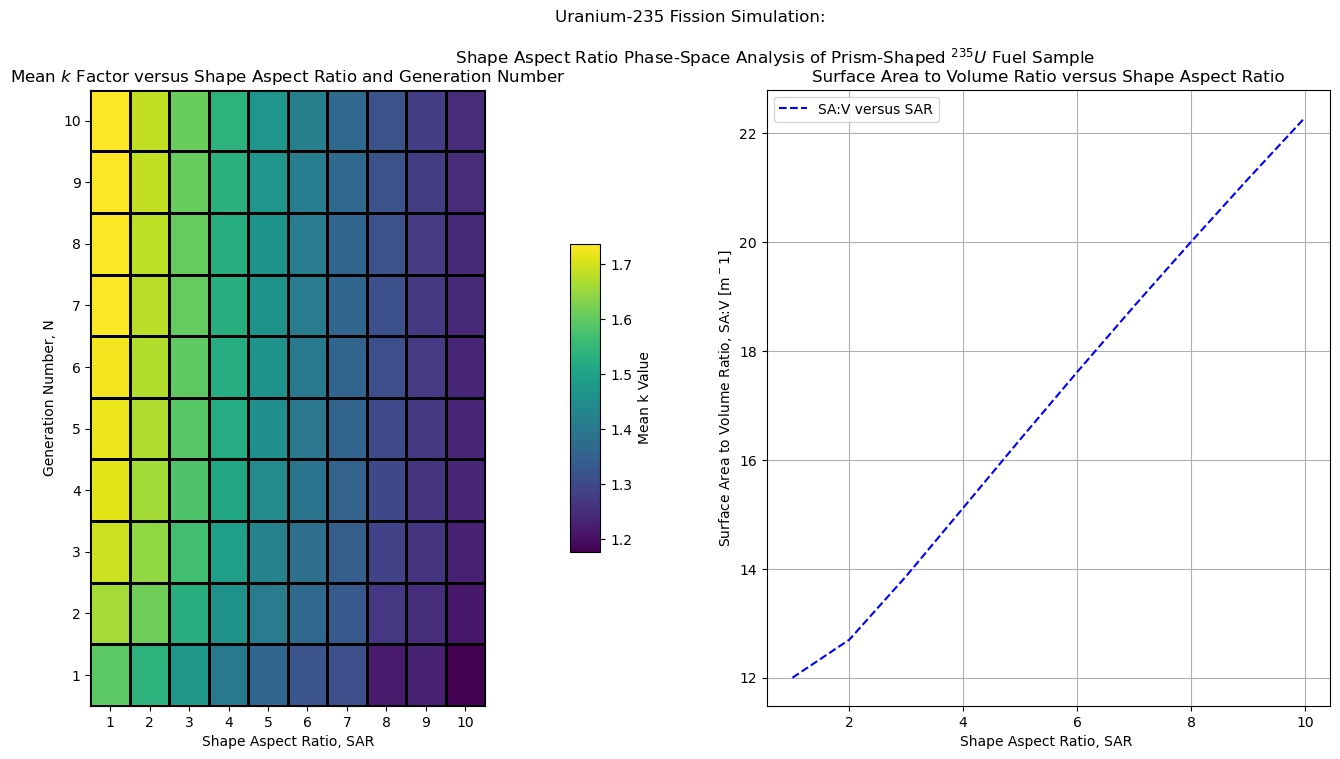

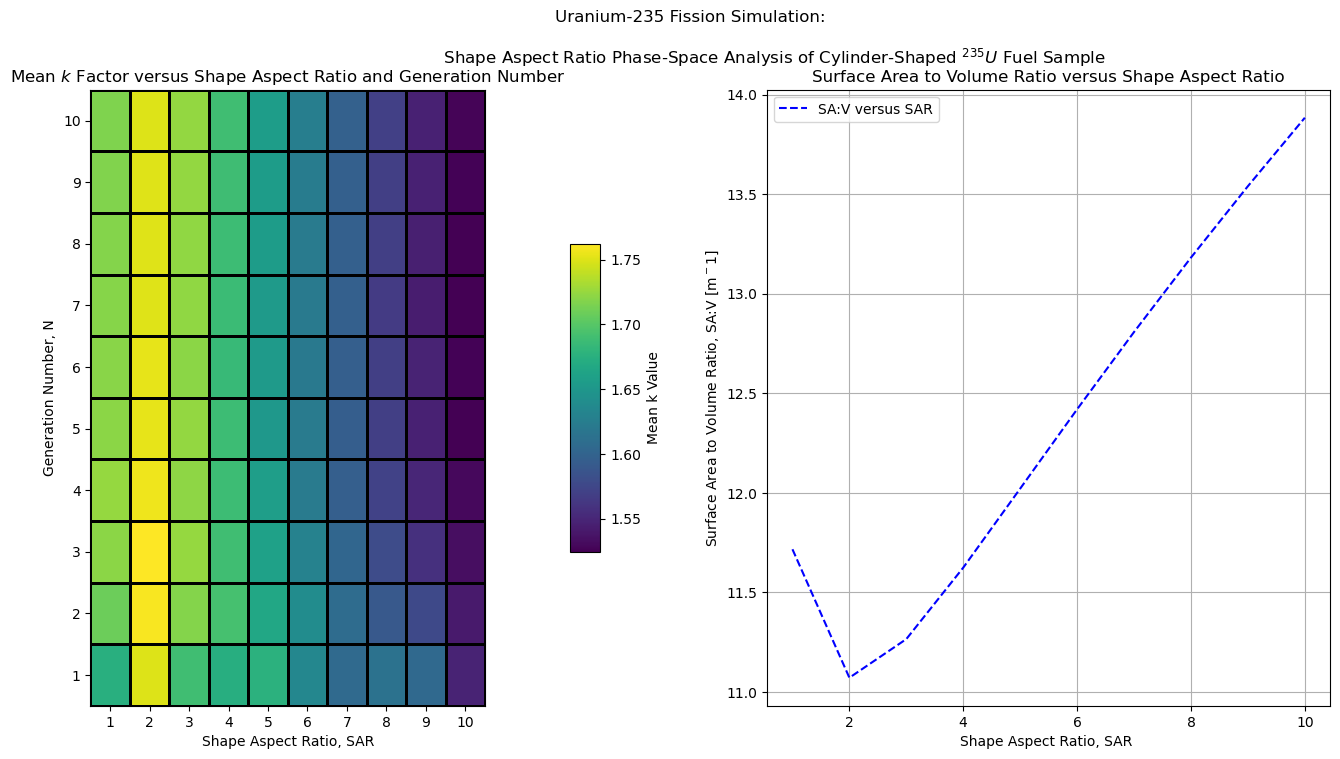

In [135]:
###############################################################################################################################################
# Definition of phase-space specific variables

# Volume for shapes with volume parameter
volume = 0.125

# Array of shape aspect ratios for phase-space analysis
shape_aspect_ratios_trials = np.linspace(1, 10, 10, endpoint=True)

# List of shape types. "cube" and "sphere" not included as they necessarily have a SAR = 1.
sample_shape_types = ["prism", "cylinder"]

###############################################################################################################################################
# Definition of arrays to store results of phase-space analysis

# Array to save results for shape aspect ratios for each of the analyses
shape_aspect_ratios = np.zeros(shape = (len(sample_shape_types), len(shape_aspect_ratios_trials)))

# Array to save results for SAtoV ratios for each of the analyses
SAtoV_ratios = np.zeros(shape = (len(sample_shape_types), len(shape_aspect_ratios_trials)))

# Array to save results for mean k-values of each generation across all trials for each of the analyses
shape_k_generations = np.zeros(shape = (len(sample_shape_types), len(shape_aspect_ratios_trials), max_generations))

###############################################################################################################################################
# Code to run the phase-space analysis

start_time_total = time.time()

for i, sample_shape_type in enumerate(sample_shape_types):
    
    for j, shape_aspect_ratio in enumerate(shape_aspect_ratios_trials):
        
        # Print simulation parameters
        start_time = time.time()
        
        # Uranium-235 Sample Parameters
        sample_shape_test_param = {"volume": volume, "shape_aspect_ratio": shape_aspect_ratio}
        
        # Instantiate and run trials for Uranium235_Fission_Model
        shape_test_simulation = Uranium235_Fission_Model(N0, mtrials, sample_shape_type, sample_shape_test_param, purity, neutron_multiplicity, mean_free_path, max_generations)
        shape_test_simulation.run_trials()
        
        # Save results to respective index within their respective array
        shape_aspect_ratios[i][j] = shape_test_simulation.shape_aspect_ratio
        SAtoV_ratios[i][j] = shape_test_simulation.surface_area/shape_test_simulation.volume
        shape_k_generations[i][j] = shape_test_simulation.k_generations.mean(axis=0)
        
        # Display histograms if hist_bool flag is True or else print the information for each trial that would be present in the histogram plot title
        if hist_bool:
            shape_test_simulation.plot_histograms()
        if verbose:
            shape_test_simulation.display_simulation_parameters()
        
        end_time = time.time()
        if time_trial:
            print(f"\nCompleted {mtrials} simulations with {N0} initial neutrons per simulation over {max_generations} generations.")
            print(f"Execution time: {end_time - start_time:.4f} seconds\n\n")

    # Plot the mean k-values versus SAR for phase-space analysis
    Uranium235_Fission_Model.plot_k_versus_shape_aspect_ratio(sample_shape_type, shape_aspect_ratios[i], SAtoV_ratios[i], shape_k_generations[i])

end_time_total = time.time()
if time_phasespace:
    print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_generations} generations across {len(shape_aspect_ratios_trials)} different SARs for {len(sample_shape_types)} shapes.")
    print(f"Total execution time: {end_time_total - start_time_total:.4f} seconds")

### Discussion of Shape Aspect Ratio Phase-Space Analysis

After performing the phase-space analysis we observed several interesting trends.

For changing SAR for the rectangular prism sample we observed that increases beyond SAR$=1$ were correlated with increases in the SA:V ratio and decreases in $k$ factor. The plot of SA:V against SAR showed that SA:V as a function of SAR ratio was increasing on our observed domain from $1\to10$; this in conjunction with the heatmap of mean $\bar{k}$ factor as a function of generation number and SAR shows that the system's behaviour was in line with our expectations; increases in SAR corresponded with increases in SA:V ratio and with observed decreases in $k$ factor as expected. We further observed that there was an initial increase in $k$ factor for early generations across all SARs with some leveling off towards the later generations.

For the cylindrical sample we observed that though there was a decrease in the SA:V ratio with an increase in SAR from $1\to2$,however for all subsequent SAR increases beyond $2$ we observed increases in the SA:V ratio. This is in line with expectations as for our investigation we have defined the cylinder SAR$=\frac{\text{height}}{\text{radius}}$, and as such having a SAR$=2$ corresponds with the cylinder being 'prism-like', where it's height is equal to it's 'width'. We note that the $k$ factor roughly followed the same trends as the prism where we observed higher $k$ factors with lower SA:V ratios; the cylinder sample with a SAR$=2$ had both the lowest SA:V as well as the highest $k$ factors across all tested values, with SAR$=1$ and all SARs$>2$ producing lower $k$ factors. For all SARs tested with the cylinder sample shape we observed a leveling trend in the $k$ factors as we reached the later generations of simulation.

Although within both shapes we observed the trend that lower SA:V ratios corresponded with higher $k$ factors, the behaviour of the cylinder was of particular interest, as the SA:V ratio did not display strictly increasing behaviour with respect to increases in SAR. We note that both SAR$=1$ and SAR$=3$ had lower SA:V ratios and correspondingly had lower $k$ factors than a cylinder with SAR$=2$. Across all tested values for the cylinder sample shape there appears to have been a preference for SARs in the range from $1\to3$ with value of $2$ having the greatest propagation of fission.

Finally, we note that the behaviour with respect to the performance (using the metric of higher $k$ factors) of each shape was in line with our expectations from the sample geometry. As we held the volume constant across all models tested, we observed that in general the cylinder was higher performing than the prism, and that the cube (prism with a SAR $=1$) was higher performing than other rectangular prisms. These results help to corroborate our assumption that SA:V ratio does play a significant role in the propogation of fission within a fuel sample.

## Phase-Space Analysis on the Effects of Volume on Multiplication Factor $k$

We will continue our analysis with a phase-space exploration on how changing sample shape volume while holding SAR constant affects the multiplication factor $k$. For the cylinder and the prism we will fix the SAR at $2$ (and for the sphere and prism the SAR is neccesarily $1$). As our prior exploration had the volume fixed at $0.125\text{ m}^3$ we will center our exploration of the volume phase-space at this value, however we will explore a range of values at equal intervals both below and above this mean.

As we will now be exploring $4$ different shapes rather than $2$, we will be reducing the depth of this phase-space exploration, evaluating $5$ different volumes at each shape rather than the $10$ different SAR as in the first analysis. This decision was made for two reasons: adding two additional shapes doubles the amount of simulations required; and running simulations at volumes much higher than $V=0.125\text{ m}^3$ becomes computationally prohibitive. 

We initially attempted to explore a range of $10$ volumes equally spaced from $0.125\text{ m}^3 \to 12.5\text{ m}^3$, however by the third trial ($V=2.875\text{ m}^3$) we were hitting simulation run-times of $\approx15\text{ min}$. We expect that with increasing volumes and fixed SAR that the resulting decrease in SA:V ratio causes more neutrons to remain within the sample and be captured, and this increased number of neutrons becomes computationally unfeasible with the server resources available.

With this we decided to focus our investigation on volumes centered on our initially explored value of $V=0.125\text{ m}^3$, evaluating at $5$ different volumes at equal intervals from $0.075\text{ m}^3 \to 0.175\text{ m}^3$. We did not want to compromise on the number of trials run, nor the number of generations examined. Though exploring a smaller range of volumes, we are still hoping to observe some trends in system behaviour, and as such it was important to maintain a large number of trials in order to collect a robust dataset, as well as maintain a large number of generations to observe trends and determine if systems reach a steady-state.

We expect to observe a positive correlation between volume and multiplication factor; increases to shape volume while holding the SAR constant should see a decrease in the SA:V ratio and we expect that to correlate with increases to the $k$ factor. Using a metric of $k$ factor as a measure of performance (where we define higher $k$ factors as higher performance), we expect to observe the sphere sample with the highest performance, followed by the cylinder, cube, and the rectangular prism with the lowest $k$ factor. This expectation is informed by the geometry of each shape, where the sphere minimizes the SA:V ratio and the prism maximizes it.

### Code to Run Shape Aspect Ratio Phase-Space Analysis

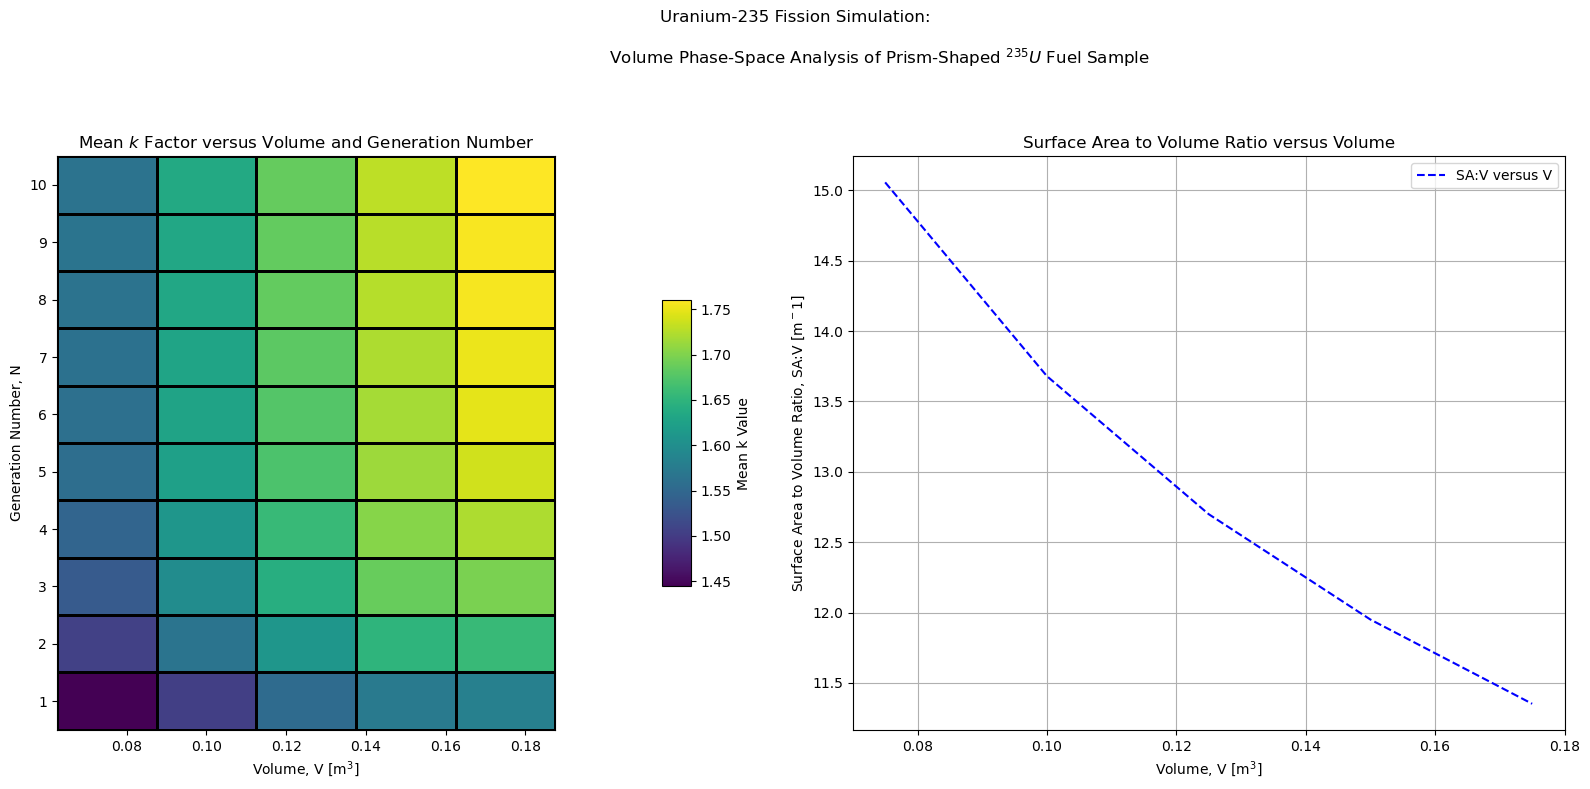

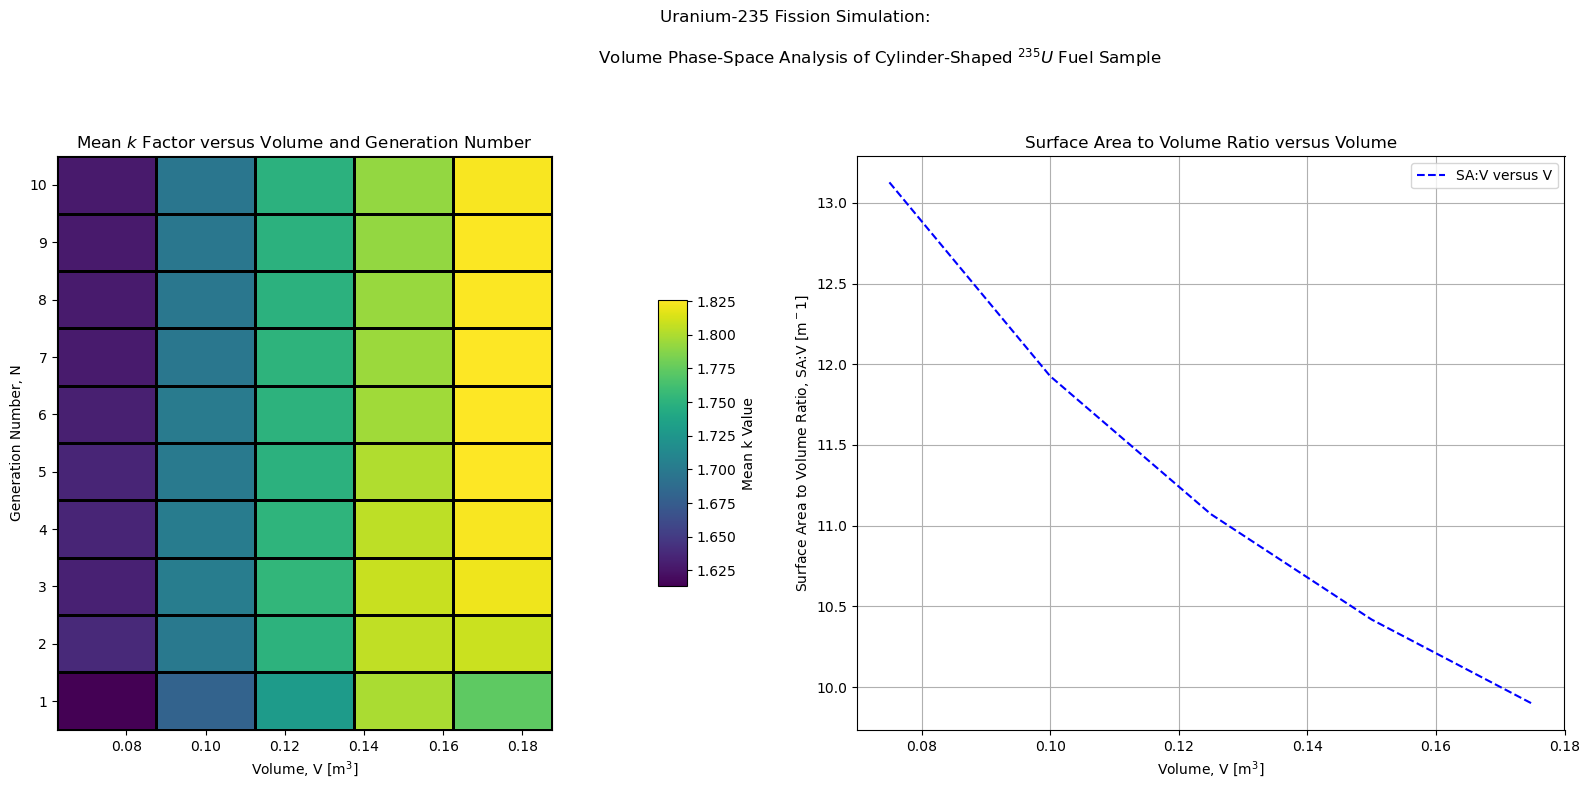

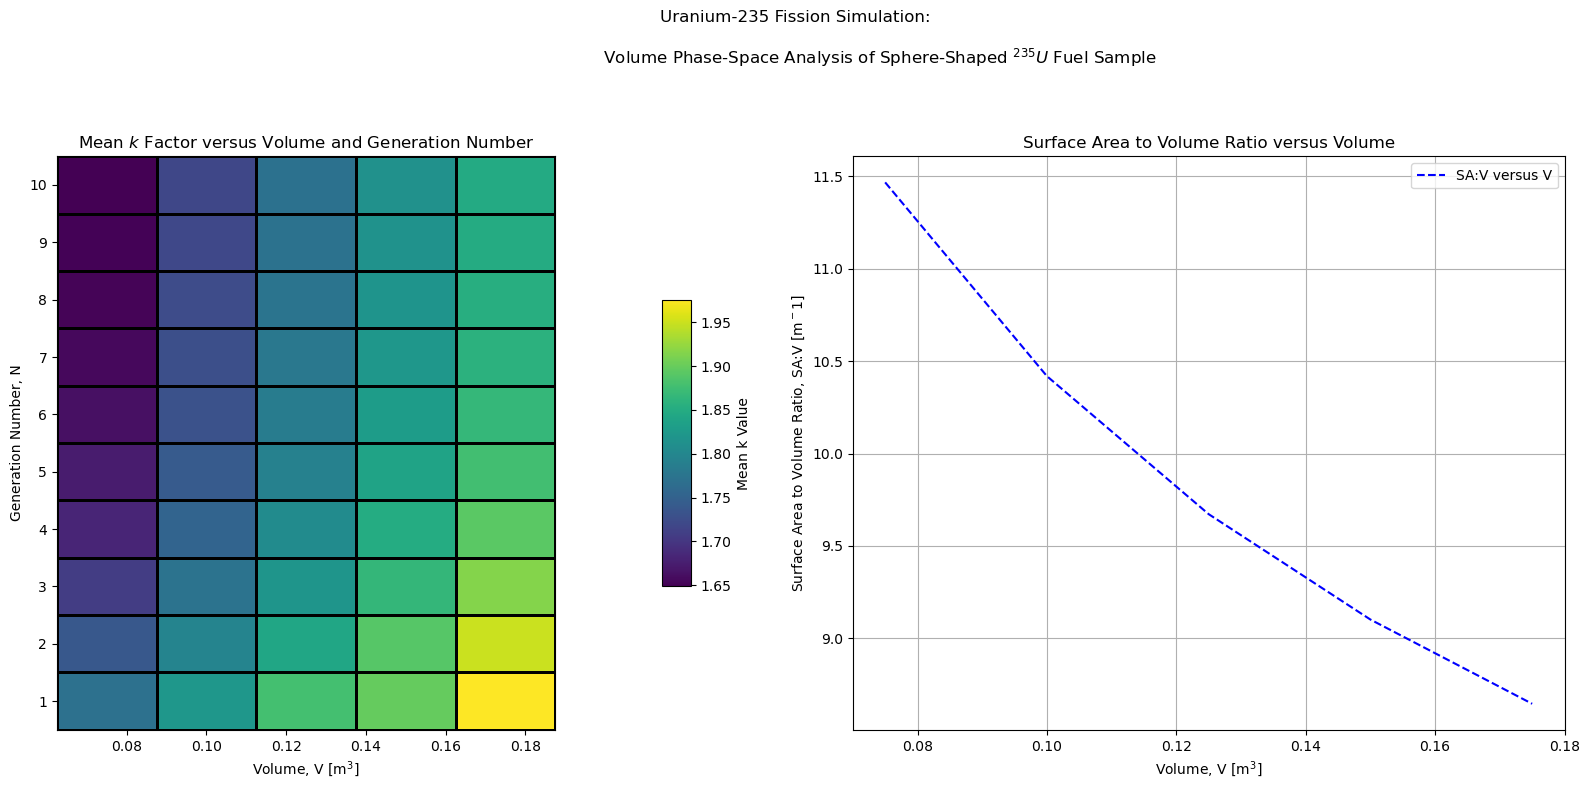

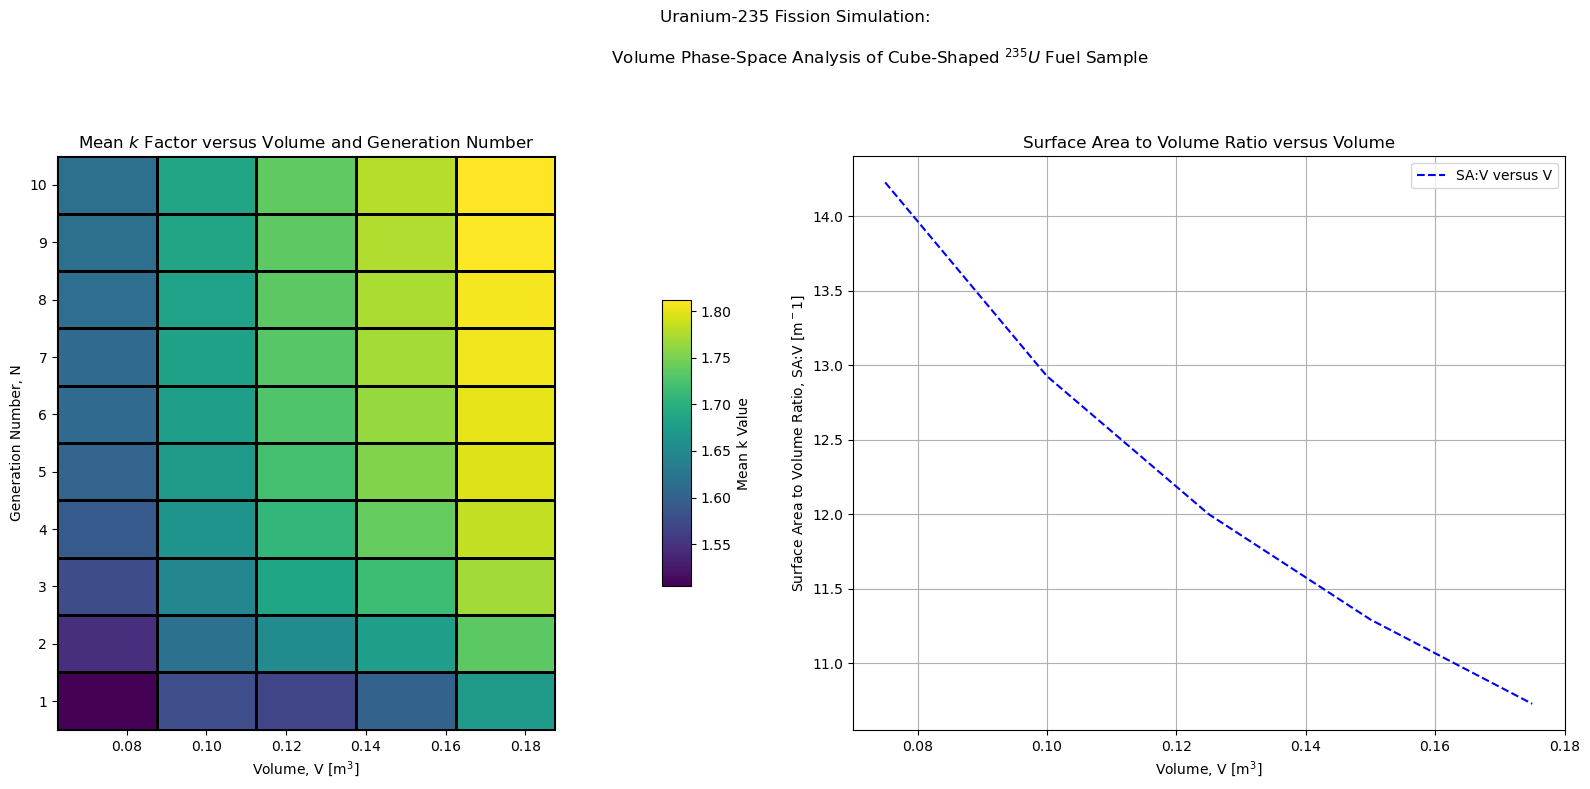

In [136]:
###############################################################################################################################################
# Definition of phase-space specific variables

# Volume for shapes with volume parameter
shape_volumes_trials = np.linspace(0.075, 0.175, 5, endpoint=True)

# Array of shape aspect ratios for phase-space analysis
shape_aspect_ratio = 2

# List of shape types. All shapes have been included for volume phase-space analysis. The shape aspect ratio used us shape_aspect_ratio = 2,
# however for volume-based construction the cube and sphere ignore this input argument as they necessarily have a shape aspect ratio of 1.
sample_shape_types = ["prism", "cylinder", "sphere", "cube"]

###############################################################################################################################################
# Definition of arrays to store results of phase-space analysis

# Array to save results for volumes for each of the analyses
shape_volumes = np.zeros(shape = (len(sample_shape_types), len(shape_volumes_trials)))

# Array to save results for SAtoV ratios for each of the analyses
SAtoV_ratios = np.zeros(shape = (len(sample_shape_types), len(shape_volumes_trials)))

# Array to save results for mean k-values of each generation across all trials for each of the analyses
shape_k_generations = np.zeros(shape = (len(sample_shape_types), len(shape_volumes_trials), max_generations))


###############################################################################################################################################
# Code to run the phase-space analysis

start_time_total = time.time()

for i, sample_shape_type in enumerate(sample_shape_types):
    
    for j, volume in enumerate(shape_volumes_trials):
        
        start_time = time.time()
        
        # Uranium-235 Sample Parameters
        sample_shape_test_param = {"volume": volume, "shape_aspect_ratio": shape_aspect_ratio}
        
        # Instantiate and run trials for Uranium235_Fission_Model
        shape_test_simulation = Uranium235_Fission_Model(N0, mtrials, sample_shape_type, sample_shape_test_param, purity, neutron_multiplicity, mean_free_path, max_generations)
        shape_test_simulation.run_trials()

        # Save results to respective index within their respective array
        shape_volumes[i][j] = shape_test_simulation.volume
        SAtoV_ratios[i][j] = shape_test_simulation.surface_area/shape_test_simulation.volume
        shape_k_generations[i][j] = shape_test_simulation.k_generations.mean(axis=0)

        # Display histograms if hist_bool flag is True or else print the information for each trial that would be present in the histogram plot title
        if hist_bool:
            shape_test_simulation.plot_histograms()
        if verbose:
            shape_test_simulation.display_simulation_parameters()
        
        end_time = time.time()
        if time_trial:
            print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_generations} generations.")
            print(f"Execution time: {end_time - start_time:.4f} seconds\n\n")

    # Plot the mean k-values versus volume for phase-space analysis
    Uranium235_Fission_Model.plot_k_versus_volume(sample_shape_type, shape_volumes[i], SAtoV_ratios[i], shape_k_generations[i])

end_time_total = time.time()
if time_phasespace:
    print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_generations} generations across {len(shape_volumes_trials)} different SARs for {len(sample_shape_types)} shapes.")
    print(f"Total execution time: {end_time_total - start_time_total:.4f} seconds")

### Discussion of Volume Phase-Space Analysis

For all shapes modeled we observed that increases to the shape volume while holding the SAR constant resulted in decreasing SA:V ratio as a function of volume which is in line with our expectations. From this, we can observe how volume affects the $k$ factor of each shape.

We also observed that for all tested sample shapes the $k$ factor increased with increases to volume. This further corroborates our results from the first phase-space, where we observed that lower SA:V ratios corresponded with higher $k$ factors.

For the rectangular prism with a fixed SAR$=2$ it was noted that the first generation $k$ factor increased upon each increase in sample volume, in line with our expectations for behaviour regarding decreases in SA:V ratio correspond. At each specified volume modeled there were initial increases in $k$ factor throughout the first few generations, with some leveling trends towards the latter generations. It is of interest that although most volumes showed leveling trends around the $5^\text{th}\to6^\text{th}$ generation, it appears as though the samples with lower volume started the levelling slightly earlier, as indicated by the color changes on the corresponding heatmap above. An area of future research may be an examination in the rate of change of $k$ factor across many generations to determine if this levelling trend does indicate a steady-state for the system.

For the cylinder sample with a fixed SAR$=2$ it was noted that their were increases in first generation $k$ factors across the first four increases of volume from $V=0.075\text{m}^3\to0.150\text{m}^3$, yet there decrease in initial $k$ factor with the final increase to $V=0.175\text{m}^3$. Despite having a lower initial $k$ factor, we observed that after the first generation the cylinder followed the same trend as the rectangular prism, where mean $\bar{k}$ factor was proportional to increases in volume and inversely proportional to SA:V ratio. It was also interesting to note that the cylinder with the highest volume had the sharpest initial increase in $k$ factor. Although the cylinder followed the same general behaviour as the rectangular prism, the unexpected behaviour with respect to the decrease in the first generation $k$ factor with the final increase to cylinder volume may be worthwhile for future investigations.

The cuboid sample had similar trends to the rectangular prism where we observed a general increase in first generation $k$ factor with increasing volume, however there was a decrease in $k$ from $V=0.100\text{m}^3\to0.125\text{m}^3$; every volume afterwards saw increases in first generation multiplication factors. Furthermore, across generations, all volumes saw increases in their $k$ factors, with some levelling trends towards the latter generations, and increases in shape volume corresponded with increased end-generation $k$ factors, with the highest volume cube having a final multiplication factor $k>1.80$.

The cuboid sample had similar trends to the rectangular prism where we observed increased $k$ factors with respect to volume along the first generation as well as increasing $k$ factors throughout generations, and again though there were some leveling trends towards the later generations we still noticed the $k$ factors increasing; more generations would need to be modeled to determine whether the propagation of fission continues to increase or levels off.

The spherical sample had interesting behaviour that was most dissimilar in comparison to the rest of the modelled shapes. Although we did observe a general increase in $k$ factor with increases to the sample volume, the $k$ factors appeared to decrease from the first generation, though still displaying some leveling behaviour towards the latter generations. This behaviour stands out in contrast to the rest of the models which saw increases in propagation over time; as such spherical sample shape models could benefit from further and targeted phase space analyses in order to better quantify their behaviour.

We observed within this phase-space analyses the general trend with respect to the performance of the different sample shapes corroborated our observations in our first phase-space analysis and were inline with our expectations. Using the metric of higher $k$ values as a measure of performance we note that the expected ordering held where we had sphere > cylinder > cube > prism. The sphere was observed to have a maximum end-generation $k$-factor of $>1.90$, the cylinder with $>1.81$, the cube with $>1.80$ and the prism with $>1.75$. These findings corroborate our assumptions that SA:V ratio is inversely proportional the the multiplication factor $k$.

## Conclusion

In this project we set out to model a simplified $^{235}U$ fission process and to examine how the geometry of the Uranium sample shape affected the multiplication factor $k$. We observed two separate geometric phase spaces: varying the SAR of the sample at a fixed volume; and varying the volume of the sample at a fixed SAR. We were interested in how these two parameters, as well as the resulting surface area to volume ratio of the shape, affected the propagation of fission within the sample; from our geometric understanding of the system we expected that SA:V ratio would be inversely proportional to the propagation of fission, as increased surface area with respect to sample volume would provide neutrons with more opportunity to pass through the sample surface and exit the system.

Our results were generally in line with expectations. We observed that increasing the sample SAR generally led to increases in SA:V ratio and to decreases to $k$ factor; conversely, increases to volume corresponded to decreases in SA:V ratio and increases to $k$ factor, with these trends holding for all four of our sample shapes. We also observed that the sample shapes with more 'efficient' SA:V ratios performed better in having higher $k$ factors, in line with our expectations and our geometric understanding of the phenomenon. There was generally some leveling trends for $k$ factors as the generations progressed, however we observed that the cylinder and spherical models showed more of a leveling trend towards a potential steady-state, with cuboid and prism models showing slightly larger increases in later generations.

There were some interesting observations made in both of the phase-space analyses. In the SAR phase-space, we observed that there may have been a 'preferred' SAR ratio for the cylinder for producing higher $k$ factors, as it was found that a SAR of $2$ produced the highest mean $k$ factor across generations, indicating that the cylinder produced it's highest fission propagation when it was 'cube-like'. We also observed within the volume phase-space that the spherical model was the only model where the $k$ factor decreased from the first generation. This phenomenon deserves further exploration with a potential for further exploration into the behaviour of the spherical model.

We note that some of the choices and assumptions made when programming this fission model were simplifying assumptions and as such the handling of fission by the model has some departures from real-world observations of $^{235}U$ fission. The number of neutrons produced per fission event in each generation was accomplished via the use of a randomized Poisson distribution with a mean set to the neutron multiplicity, however this produces a range of integer values from $0$ to numbers greater than 3; this is a departure from reality as literature values state that $^{235}U$ fission produces either 2 or 3 new neutrons $^{[2]}$ (with a mean value of $2.4355^{[1]}$). The choice of using a Poisson distribution was made as it allowed for both a random number of neutrons to be produced for each captured neutron, as well as setting the mean value of the distribution to adhere to the neutron multiplicity; other methods attempted to generate a random distribution either did not allow for setting a mean for the distribution or did not produce integer values. Custom methods of generating arrays with the proper distribution were attempted, however we found that there were issues in generating distributions of sufficient length with a mean sufficiently close to the desired multiplicity that were not able to be overcome. As such we decided that using a Poisson distribution to incorporate neutron multiplicity was a worthwhile trade-off. We also note that in our simplified model all neutrons present and produced via fission are considered thermal neutrons, however in the actual $^{235}U$ fission process the neutrons produced via fission are initially fast neutrons $^{[2]}$. This was a simplifying assumption that was made in order to focus the efforts of the investigation on the geometry of the fuel sample itself. However both of these simplifying assumptions provide very clear directions for future investigations and next steps in model development.

Further development of randomizing the number of neutrons produced per event while adhering to the neutron multiplicity would allow for this model to better approximate the fission process. Another direction for further development would be the inclusion of fast neutrons as fission products, moderators outside of the fuel sample, and nuclear reflectors surrounding the sample itself; although we were interested in implementing these features it was outside of the scope of our investigation, however the modular development of the Uranium235-fission class would allow for the implementation of these physical extensions without having to refactor much of the existing code. As the model already incorporates a variety of shapes — as well as methods for evaluating when trajectories exit boundaries — implementing nuclear reflectors surrounding the sample could use the existing in-built functionality. We note that often graphite and heavy water are used as moderators $^{[2]}$ in reactors; as such further development of the model could include surrounding a sample by water within a container of nuclear reflectors. Adding these additional physical phenomena could be accomplished by: incorporating neutron energy with defined levels for fast/thermal neutrons (i.e. 1 MeV for fast neutrons, 0.02 eV for thermal neutrons $^{[2]}$); including different mean free path values for each material where mean free path could be a function of neutron energy $^{[4]}$; creating methods to determine the point of exit of neutrons from the $^{235}U$ sample such that trajectories entering/leaving different materials could be adjusted according to differing mean free paths; and incorporating collision mechanics for the water and nuclear reflectors with associated neutron energy loss. 

Overall, we found that the geometry of the sample shape affects the multiplication factor $k$ and the propagation of fission. The results support our assumptions that in general SA:V is inversely proportional to the propagation of fission within the sample, with lower surface areas with respect to sample volume being related with increases in the number of captured neutrons in each generation.

## References

**Academic References**
1. PHYS 210 Project 3 Instructions - https://physics210.github.io/p210-2024/Project03-Instructions.html
2. Physics of Uranium and Nuclear Fission - https://world-nuclear.org/information-library/nuclear-fuel-cycle/introduction/physics-of-nuclear-energy
3. Neutron Multiplicity: University of Liverpool - https://ns.ph.liv.ac.uk/~ajb/radiometrics/neutrons/reactor/neutron%20multiplicity.htm
4. Monte Carlo Studies on Neutron Interactions
in Radiobiological Experiments - https://www.researchgate.net/publication/318413306_Monte_Carlo_studies_on_neutron_interactions_in_radiobiological_experiments

**Python References**

1. Associating Class Dictionary Keys with Class Methods by String Values - https://stackoverflow.com/questions/26663032/calling-python-dictionary-of-function-from-class
2. Python Documentation: getattr() - https://docs.python.org/3/library/functions.html#getattr
3. Matplotlib Surface Plots and 3D Projections - https://matplotlib.org/stable/gallery/mplot3d/surface3d.html
4. Matplotlib Formatting Surface Plots - https://stackoverflow.com/questions/21418255/changing-the-line-color-in-plot-surface
5. Numpy Array Column Stack = https://numpy.org/doc/stable/reference/generated/numpy.column_stack.html
6. Matplotlib Subplots Suptitle - https://www.geeksforgeeks.org/how-to-set-a-single-main-title-for-all-the-subplots-in-matplotlib/
7. Numpy Array Transpose - https://numpy.org/doc/2.1/reference/generated/numpy.matrix.transpose.html
8. $\LaTeX$ Formatting in Python - https://stackoverflow.com/questions/4028267/how-to-render-latex-markup-using-python
9. Dynamically Size / Remove Axes from Subplots - https://matplotlib.org/stable/api/figure_api.html
10. Using Time Library - https://stackoverflow.com/questions/1557571/how-do-i-get-time-of-a-python-programs-execution
11. Matplotlib pcolormesh - https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html
12. ChatGPT - Used for help in interpreting error codes that popped up throughout the coding process. Some of the specific instances where ChatGPT was helpful and was able to point me in the right direction was with the surface plots; I was running into shape issues when trying to plot the surface plot and ChatGPT pointed me in the direction of needing to perform a matrix transpose in order to have my k-generations data in the right format. ChatGPT also pointed me in the direction of using np.column_stack in order to properly format my direction vectors. ChatGPT was also used in refactoring some of the main class methods in order to store position and direction data and plot associated trajectories for validation in Appendix A1.4; the position and direction data was not initially stored in the model and generative AI was useful in accomplishing this fairly significant refactoring in order to validate trajectory behaviour.

## Appendix 1: Code validation

### A1.1: Verification of Simple and Extended Model on Provided Initial Conditions

The first verification that I performed when building this models was that the behaviour was as expected over multiple iterations on the provided data from the project instructions.

I began by building a simple Class in order to handle only the cube dimensions provided, where we had a $^{235}U$ with
$$
\begin{align}
    \text{side length } a &= 0.50\text{m} \\
    \text{mean free path } \lambda &= 0.15\text{m} \\
    \text{initial number thermal neutrons } N_0 &= 150 \\
    \text{maximum generation } N_3 &= 3 \\
    m_{\text{trials}} &= 250
\end{align}
$$

When the model was able to reproduced the expected results I began adding incremental complexity to the model while testing at each iteration with the provided initial conditions.

The first addition to the Class definition was the implementation of a class dictionary for shape types and associated dimension values. The programming for shapes included both dimension-based and volume-based (where possible) construction of the class shapes. Following this the parameter 'purity' was added to the class, where purity is proportional to the probability of a captured neutron undergoing a fission reaction; this value can range from 1 (guaranteed fission propogation) to 0 (no fission propogation). The mean number of neutrons produced per fission event (neutron multiplicity) $\left(^{235}U = 2.4355\right)$ was also implemented to add more realism to the model.

Several qualitative tests were done to verify that the shapes were behaving as expected. I first ran the "cube" model with the same initial parameters and verified replicability of results within the expected range; this was also done for a "prism" where $\text{length}=\text{width}=\text{height}=0.5\text{m}$. In both cases the results were as expected. 

In order to qualitatively determine whether the sphere and cylinder were behaving as expected the volume-based construction method was used. The initial "cube" parameters produced a "cube" model with volume $\text{V}=0.125\text{m}^3$, and this value was then used in the construction of "cylinder" and "sphere" models. The metric of observation for this qualitative analysis is the multiplication factor $k$, where we believe the surface area:volume (SA:V) ratio would be inversely proportional to the $k$ value; a higher SA:V ratio would provide more boundary area as a function of volume where the neutrons would have the ability to interact with / escape from these boundaries. As such we expect to see a trend for mean value for the multiplication factor $\bar{{k}}$ with respect to shape where "cube" = "prism" < "cylinder" < "sphere".

#### Python Code to Run Model Shape Tests on Provided Initial Conditions


The following Python code block instantiates and executes the model tests across these shapes with the initial parameters. It is of note that there was one change to the provided initial conditions, where $m_{\text{trials}}$ was increased from $250$ to $1000$ in order to collect a more robust data set for $k$ values from which to calculate the mean and standard deviation.

This will test a "cube" and a "prism" model of equal dimensions, to be compared against the expected results within the lab instructions for these input parameters, and will also test a "cylinder" and "sphere" model of equal volume to the "cube".

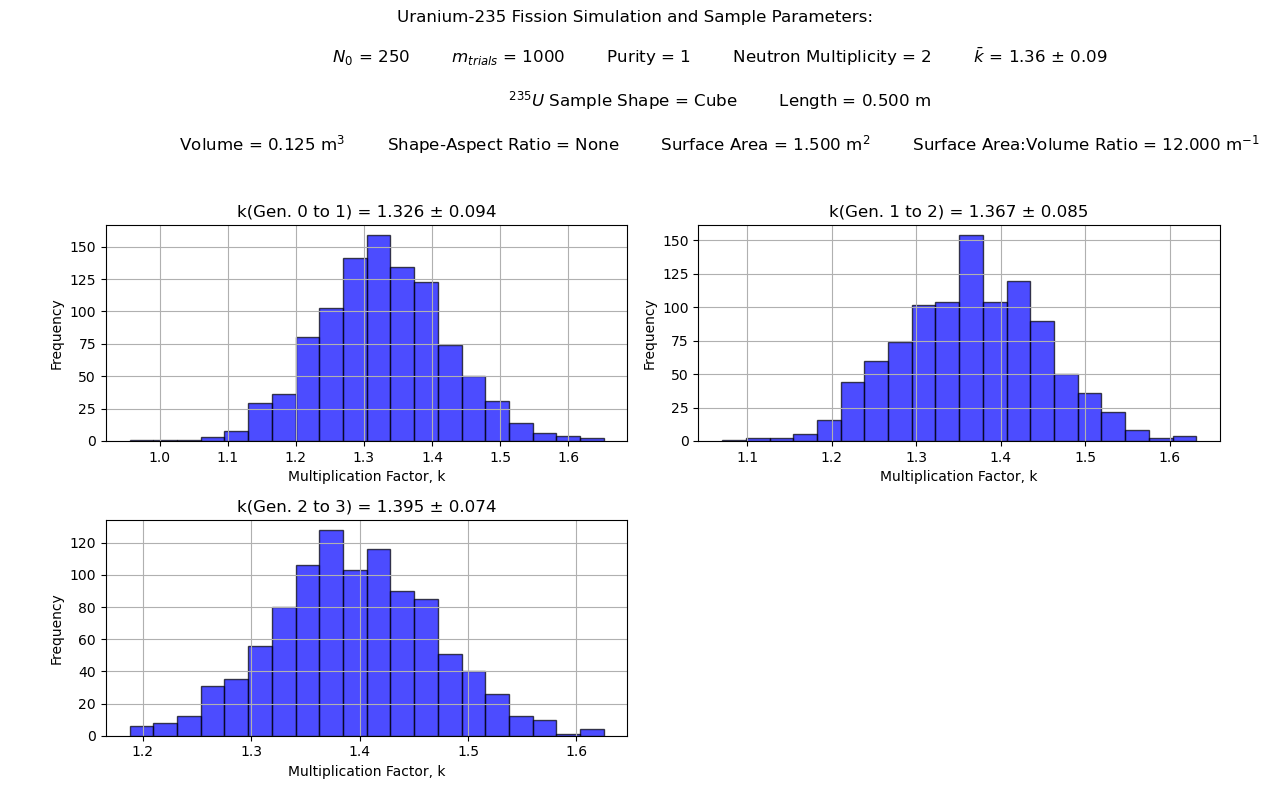

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 2.7565 seconds


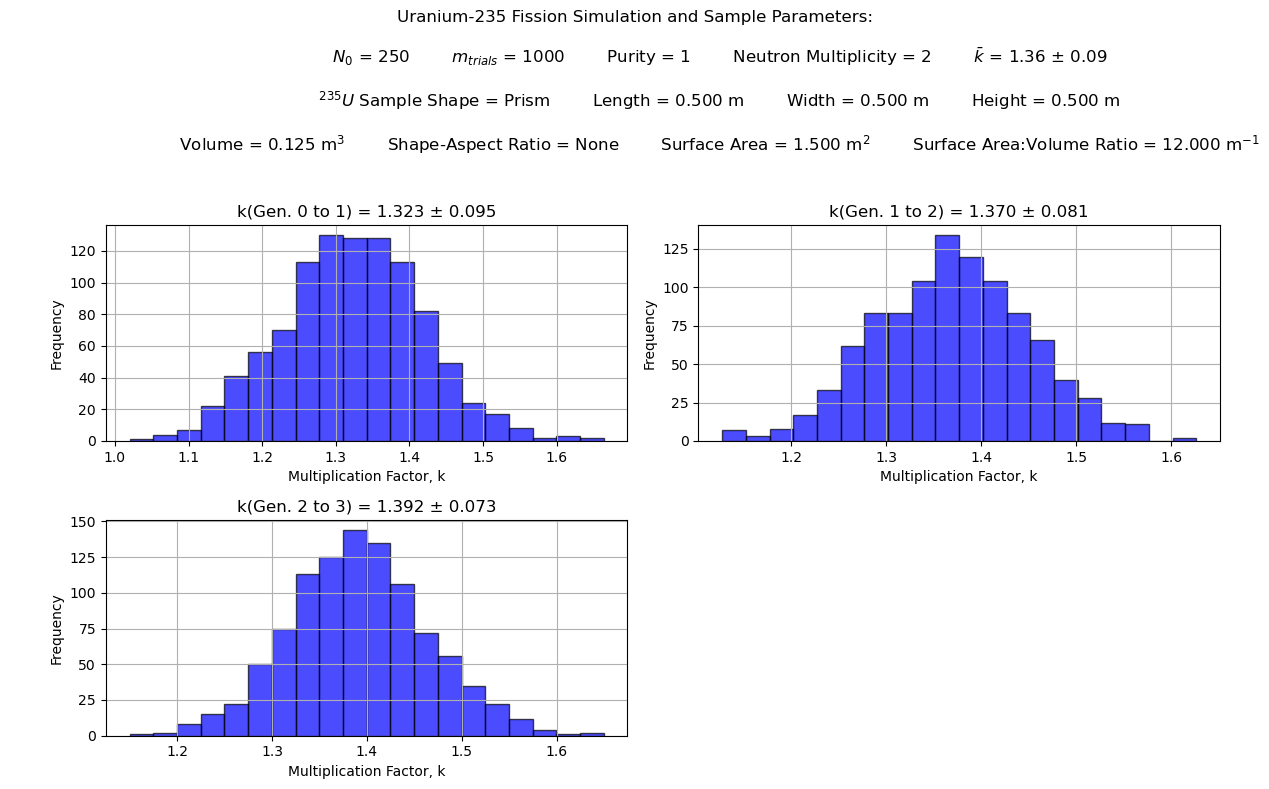

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 2.7522 seconds


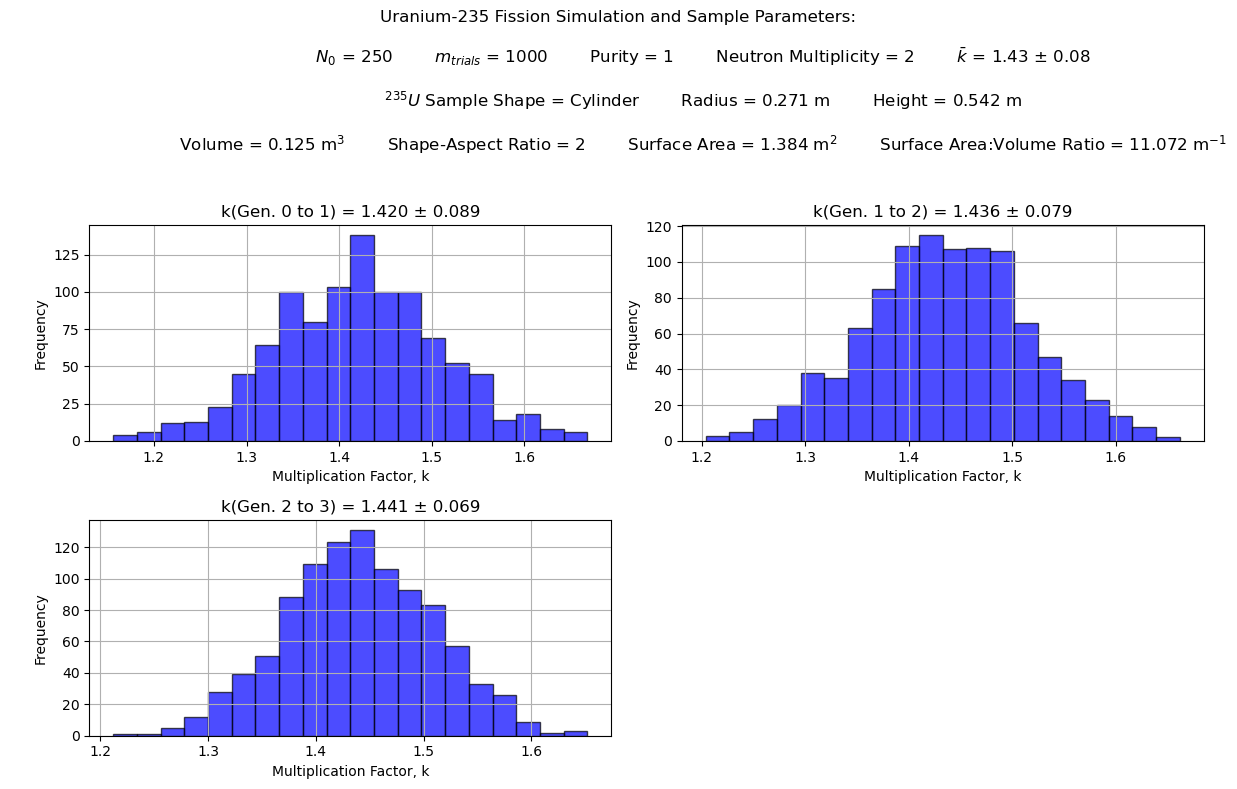

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 3.3164 seconds


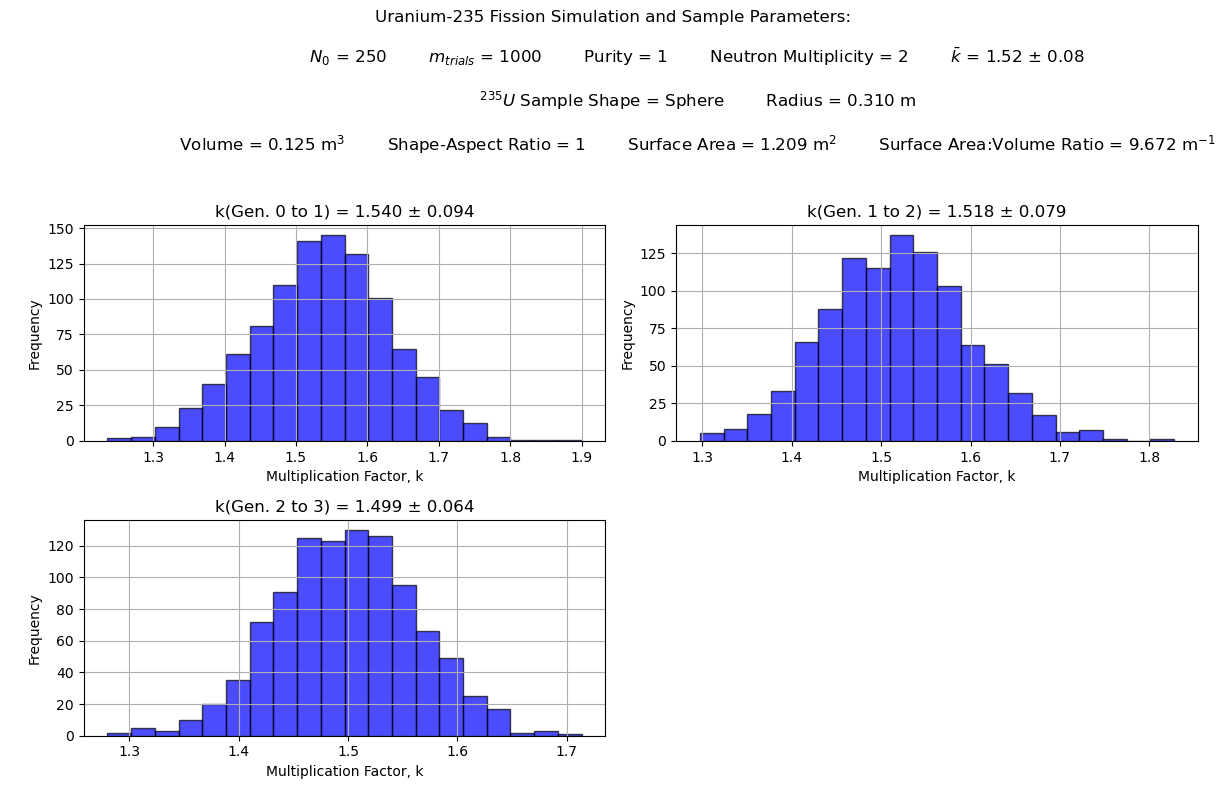

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 6.5527 seconds


In [137]:
# Define common variables to be used across test-cases

# Number of starting protons N0
N0 = 250

# Number of trials to run
mtrials = 1000

# Max generations
max_gen = 3

# Fermi's best guess of the mean free path
# based on the neutron cross section in U235
mean_free_path = 0.15 # m

# Purity proportional to the probability that an absorbed nucleus undergoes fission
purity = 1

# Number of new neutrons per fission event
neutron_multiplicity = 2

# Length for shapes with length parameter
length = 0.5

# Volume for shapes with volume parameter
volume = length**3

###############################################################################################################################################

# Run test on "cube" model
start_time = time.time()

# Uranium-235 Sample Shape
cube_test = "cube"

# Uranium-235 Sample Parameters
cube_test_param = {"dimensions":{"length": length}}

# Instantiate and run trials for Uranium235_Fission_Model
shape_test_cube = Uranium235_Fission_Model(N0, mtrials, cube_test, cube_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
shape_test_cube.run_trials()
shape_test_cube.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")


# Run test on "prism" model
start_time = time.time()
prism_test = "prism"

# Uranium-235 Sample Parameters
prism_test_param = {"dimensions":{"length": length, "width": length, "height": length}}

# Instantiate and run trials for Uranium235_Fission_Model
shape_test_prism = Uranium235_Fission_Model(N0, mtrials, prism_test, prism_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
shape_test_prism.run_trials()
shape_test_prism.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")


# Run test on "cylinder" model
# Uranium-235 Sample Shape
start_time = time.time()
cylinder_test = "cylinder"

# Uranium-235 Sample Parameters
cylinder_test_param = {"volume": volume, "shape_aspect_ratio": 2}

# Instantiate and run trials for Uranium235_Fission_Model
shape_test_cylinder = Uranium235_Fission_Model(N0, mtrials, cylinder_test, cylinder_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
shape_test_cylinder.run_trials()
shape_test_cylinder.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")

# Run test on "sphere" model
sphere_test = "sphere"

# Uranium-235 Sample Parameters
sphere_test_param = {"volume": volume}

# Instantiate and run trials for Uranium235_Fission_Model
shape_test_sphere = Uranium235_Fission_Model(N0, mtrials, sphere_test, sphere_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
shape_test_sphere.run_trials()
shape_test_sphere.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")

#### Analysis of Results from Model Shape Tests

The results from our qualitative analysis on the shapes indicate that they are behaving as expected. It was observed that the mean multiplication factor $\bar{{k}}$ was similar for both the "cube" and "prism" model of equal dimensions with both having $\bar{k}=1.36\pm0.09$. We also note that the "cylinder" model outperformed both the "cube" and "prism" for a cylinder of equal volume ($\bar{k} = 1.43\pm0.08$), and that the "sphere" outperformed all other models with the lowest SA:V ratio and highest mean multiplication factor ($\bar{k}=1.52\pm0.08$). This is in line with our expectations given the geometry of each system. Futhermore, we observe that the range of k values for each shape is Gaussian in nature and that for the "cube" model we are around the range of expected results from the test conditions given in the project instructions.

### A1.2 Verification of Purity Factor on Provided Initial Conditions

In order to qualitatively analyze the behaviour with respect to the purity value "cube" models will be tested with purity values $\{0, 0.5, 1\}$ using the provided initial testing conditions. We expect to see no propagation for a purity of $0$, results similar to those provided in the project instructions for a purity of $1$, and a $k$ value approximately halved for a purity of $0.5$.

#### Python Code to Run Purity and Propagation Tests on "Cube" Model

The following code block instantiates and runs purity tests and tests on neutron multiplicity on a "cube" model with the provided side length $0.5\text{m}$. It is of note that during this series of tests the number of trials $m_{{\text{trials}}}$ was also increased to $1000$ for a more robust data set.

The models will be run in the order: (1) purity = $0$; (2) purity = $0.5$; and (3) purity = $1$. This order will allow for the model of provided initial conditions to be compared to both groups of data above with respect to purity.

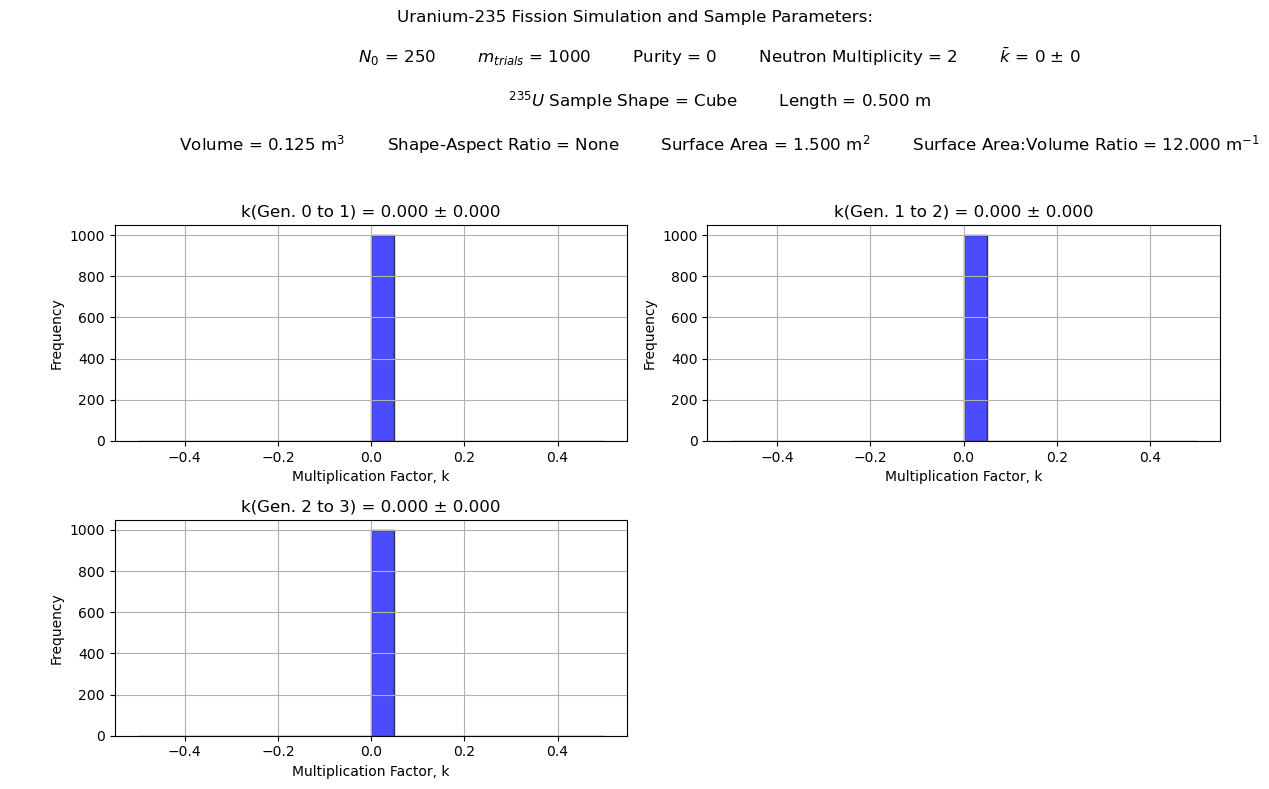

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 1.1686 seconds


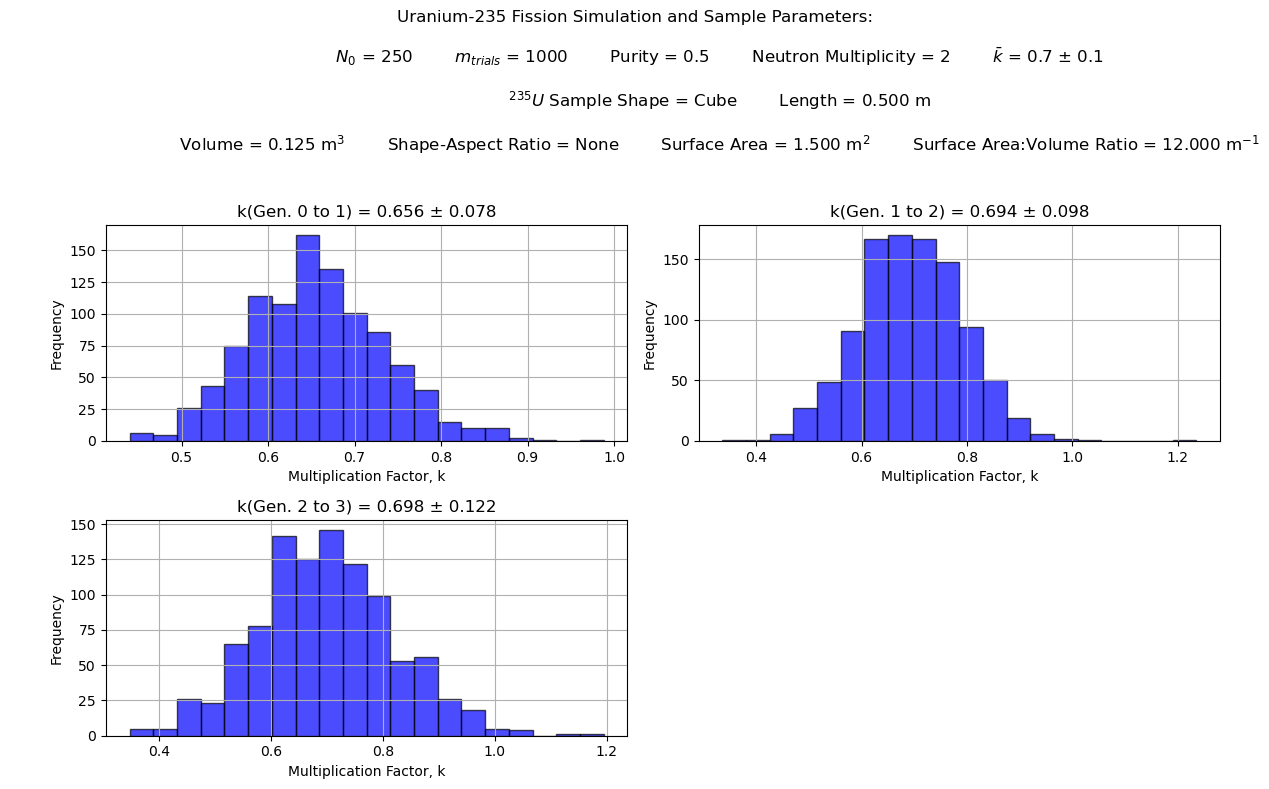

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 1.8156 seconds


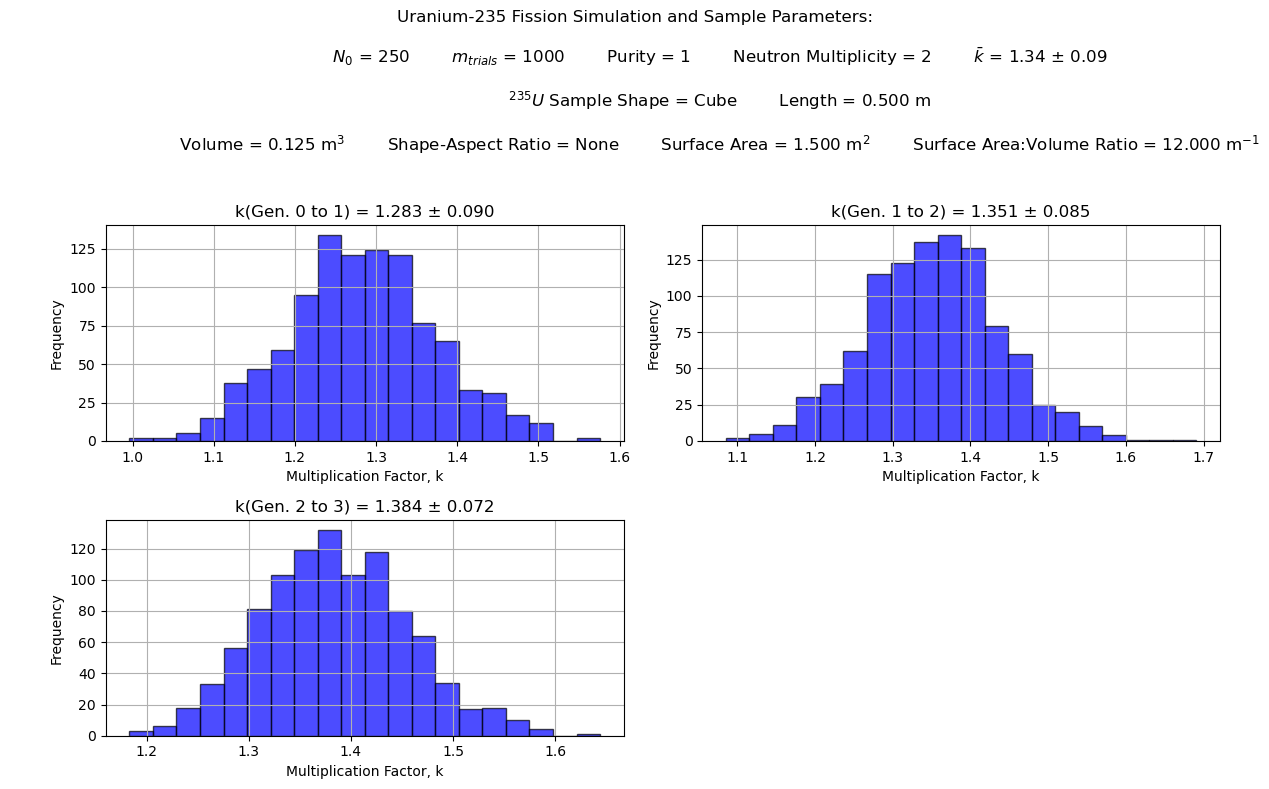

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 2.7968 seconds


In [138]:
# Define common variables to be used across test-cases

# Number of starting protons N0
N0 = 250

# Number of trials to run
mtrials = 1000

# Max generations
max_gen = 3

# Fermi's best guess of the mean free path
# based on the neutron cross section in U235
mean_free_path = 0.15 # m

# Number of new neutrons per fission event
neutron_multiplicity = 2

# Length for shapes with length parameter
length = 0.5

# Volume for shapes with volume parameter
volume = length**3

###############################################################################################################################################

# Run test on "cube" model with purity = 0
start_time = time.time()

# Uranium-235 Sample Shape
purity_test0 = "cube"

# Uranium-235 Sample Parameters
purity_test0_param = {"dimensions":{"length": length}}

# Set purity of sample
purity = 0

# Instantiate and run trials for Uranium235_Fission_Model
purity_test_model0 = Uranium235_Fission_Model(N0, mtrials, purity_test0, purity_test0_param, purity, neutron_multiplicity, mean_free_path, max_gen)
purity_test_model0.run_trials()
purity_test_model0.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")


# Run test on "cube" model with purity = 0.5
start_time = time.time()

# Uranium-235 Sample Shape
purity_test_half = "cube"

# Uranium-235 Sample Parameters
purity_test_half_param = {"dimensions":{"length": length}}

# Set purity of sample
purity = 0.5

# Instantiate and run trials for Uranium235_Fission_Model
purity_test_model_half = Uranium235_Fission_Model(N0, mtrials, purity_test_half, purity_test_half_param, purity, neutron_multiplicity, mean_free_path, max_gen)
purity_test_model_half.run_trials()
purity_test_model_half.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")


# Run test on "cube" model with purity = 1
start_time = time.time()

# Uranium-235 Sample Shape
purity_test1 = "cube"

# Uranium-235 Sample Parameters
purity_test1_param = {"dimensions":{"length": length}}

# Set purity of sample
purity = 1

# Instantiate and run trials for Uranium235_Fission_Model
purity_test_model1 = Uranium235_Fission_Model(N0, mtrials, purity_test1, purity_test1_param, purity, neutron_multiplicity, mean_free_path, max_gen)
purity_test_model1.run_trials()
purity_test_model1.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")

#### Analysis of Purity Factor Model Tests

It was observed that in all cases tested that the model behaved as expected. For the model with $\text{purity} = 0$ it was observed that the only multiplication factor $k$ produced was $k=0$ as expected, and the model with $\text{purity} = 0.5$ produced an average multiplication factor $\bar{{k}} = 0.7$ which is approximately half of the mean value produced for $\text{purity} = 1$.

### A1.3: Validation of Neutron Multiplicity on Provided Initial Conditions

To qualitatively analyze the behaviour with respect to neutron multiplicity, "cube" models will be tested with this value set to $2$ (as in the provided initial test conditions where every fission event produced two neutrons) as well as the value for $^{{235}}U = 2.4355$. The expectation is that a value of $2.4355$ will result in a higher $k$ value than the initial conditions.

### Python Code to Neutron Multiplicity Model Tests

The following code block instantiates and runs tests on neutron multiplicity on a "cube" model with the provided side length $0.5\text{m}$. It is of note that during this series of tests the number of trials $m_{{\text{trials}}}$ was also increased to $1000$ for a more robust data set.

The models will be run in the order: (1) neutron multiplicity = $2$; and (2) neutron multiplicity = $2.4355$. This order will allow for the model of provided initial conditions to be compared to data below with respect to neutron multiplicity.

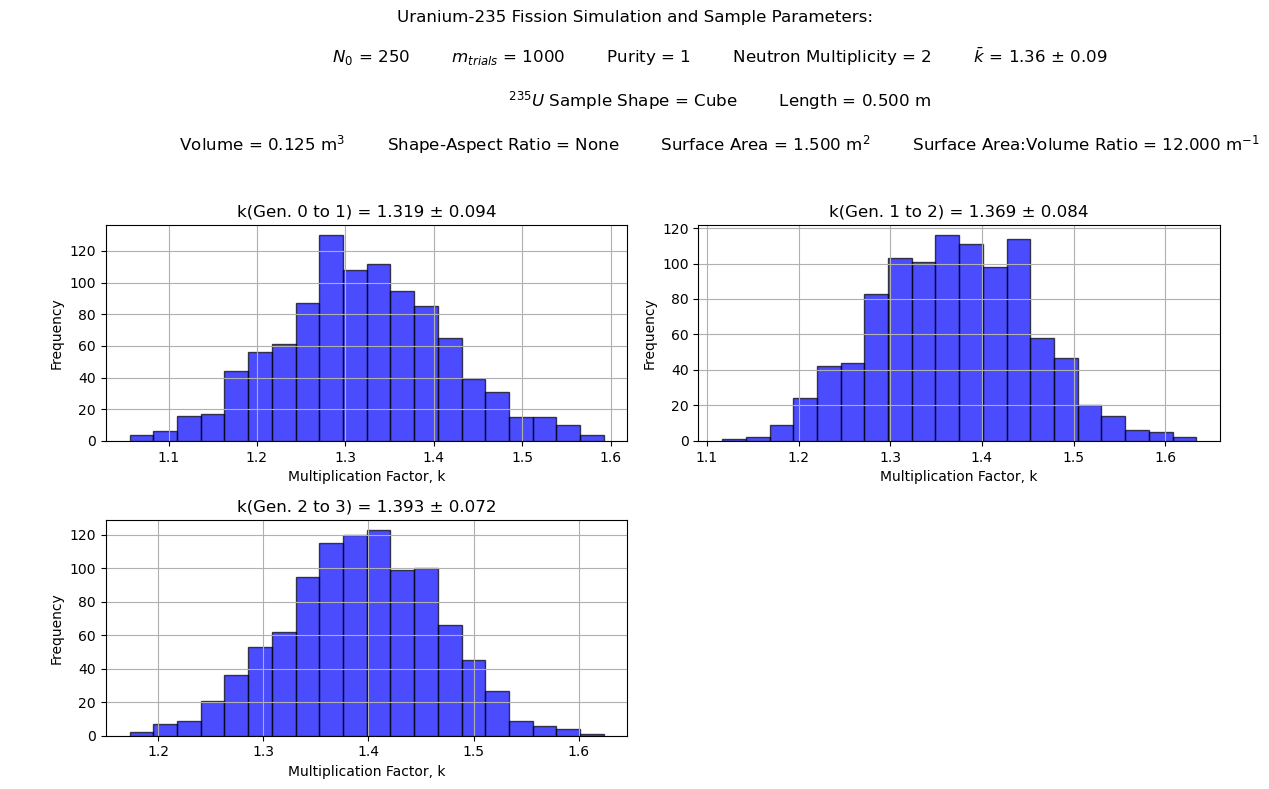

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 2.7825 seconds


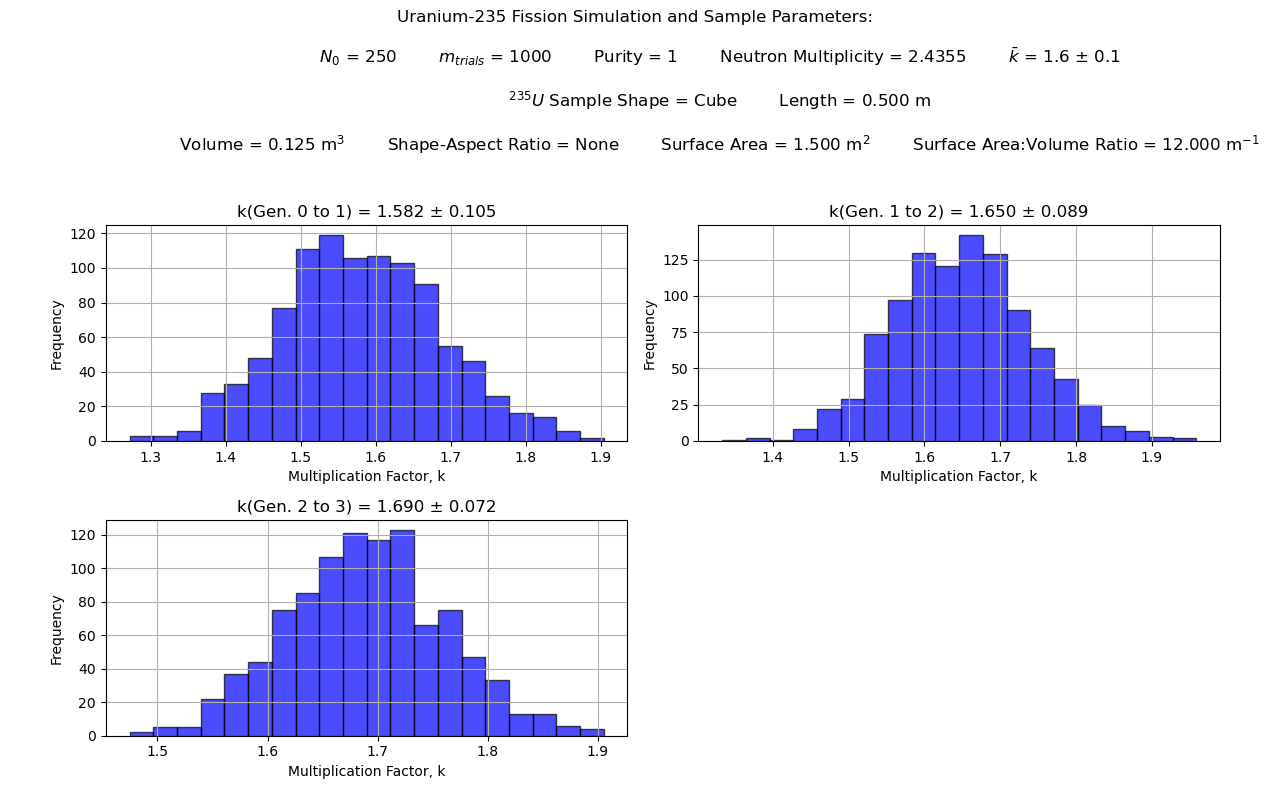

Completed 1000 simulations with 250 initial neutrons per simulation over 3 generations.
Execution time: 3.4519 seconds


In [139]:
# Run test on "cube" model with neutron_multiplicity = 2.4355
start_time = time.time()

# Uranium-235 Sample Shape
multiplicity_test = "cube"

# Uranium-235 Sample Parameters
multiplicity_test_param = {"dimensions":{"length": length}}

# Set purity of sample
neutron_multiplicity = 2

# Instantiate and run trials for Uranium235_Fission_Model
multiplicity_test_model = Uranium235_Fission_Model(N0, mtrials, multiplicity_test, multiplicity_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
multiplicity_test_model.run_trials()
multiplicity_test_model.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")

# Run test on "cube" model with neutron_multiplicity = 2.4355
start_time = time.time()

# Uranium-235 Sample Shape
multiplicity_test = "cube"

# Uranium-235 Sample Parameters
multiplicity_test_param = {"dimensions":{"length": length}}

# Set purity of sample
neutron_multiplicity = 2.4355

# Instantiate and run trials for Uranium235_Fission_Model
multiplicity_test_model_24355 = Uranium235_Fission_Model(N0, mtrials, multiplicity_test, multiplicity_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
multiplicity_test_model_24355.run_trials()
multiplicity_test_model_24355.plot_histograms()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")

### Analysis of Neutron Multiplicity Model Tests

In the model testing the propogation factor we compared a propogation factor $2.4355$ against the initial factor $2$. Taking the ratio of the two factors $\frac{2.4355}{2} = 1.21775$ if we look at the mean $\bar{{k}}$ values for each data set, we observe that $\bar{{k}}_{{2.4355}} = 1.6 \approx \frac{2.4355}{2}\cdot1.36 = \frac{2.4355}{2}\cdot\bar{{k}}_2$ and again that our model is behaving as expected with respect to the propogation factor.

### A1.4 Verifying Neutron Trajectories

In order to verify that the model is behaving as expected with respect to the positions and trajectories of neutrons within the sample, several class methods were copied with small changes and refactoring of the code into trajectory-specific methods to test and observe the trajectories of a small number of initial neutrons across several generations. 

The class methods to run the phase-space analysis did not store information about neutron position or direction vectors across generations; as this was not within the scope of the phase-space analysis, the program only stored information relating to the $k$ factor across generations in order to be as memory efficient as possible. As such, several class methods were copied and repurposed for the express purpose of validating the trajectory. Within these trajectory-specific classes, no information regarding $k$ factors was stored; instead data regarding position, direction, and number of neutrons per generation were stored and returned. From this four trajectory plots were produced: (1) 3D quiver plot of trajectory in 3D space; and 2D projection of trajectories into each of the (2) XY-plane, (3) XZ-plane and (4) YZ-plane. The sample boundary was also displayed as a black square/cube surrounding the sample to clearly dilineate when a neutron leaves the sample.

For the validation, we expect that from the initial neutron that its respective direction vector that will directly connect to the position of the next generation's neutron. Within this model we have set the neutron multiplicity to guarantee 2 neutrons per fission event, so from each neutron still within the sample we expect to see two new direction vectors leading from it towards it's next position, and for it to continue in this manner across generations so long as the neutrons remain within the sample. Each generation has been colour coded in order to clearly distinguish the behaviour of the system, and 2D projections have been plotted to give clarity in scenarios where it may be hard to distinguish what is occuring due to the aspect of the 3D plot.

#### Python Code for Neutron Trajectory Test

Following is the python code to instantiate and run the trajectory test. In order for clarity we are starting with a single initial neutron and are running four generations to validate that the movement of the neutrons are behaving as expected. As the initial system model did not keep or store any information regarding position or direction across the generations, there was substantail refactoring/reworking of methods required in order to produce the trajectory plots; as such we used the assistance of generative AI to refactor our already written methods for these purposes.

We are wanting to validate several aspects of the trajectory behaviour: that the positions of neutrons in subsequent generations are being properly calculated from the direction vectors; that each neutron remaining within the sample are generating two additional neutrons upon fission such that for every generation $N>0$ we should see two trajectories coming from these neutrons; and that neutrons leaving the sample are removed from the system with no further trajectories being calculated for them.

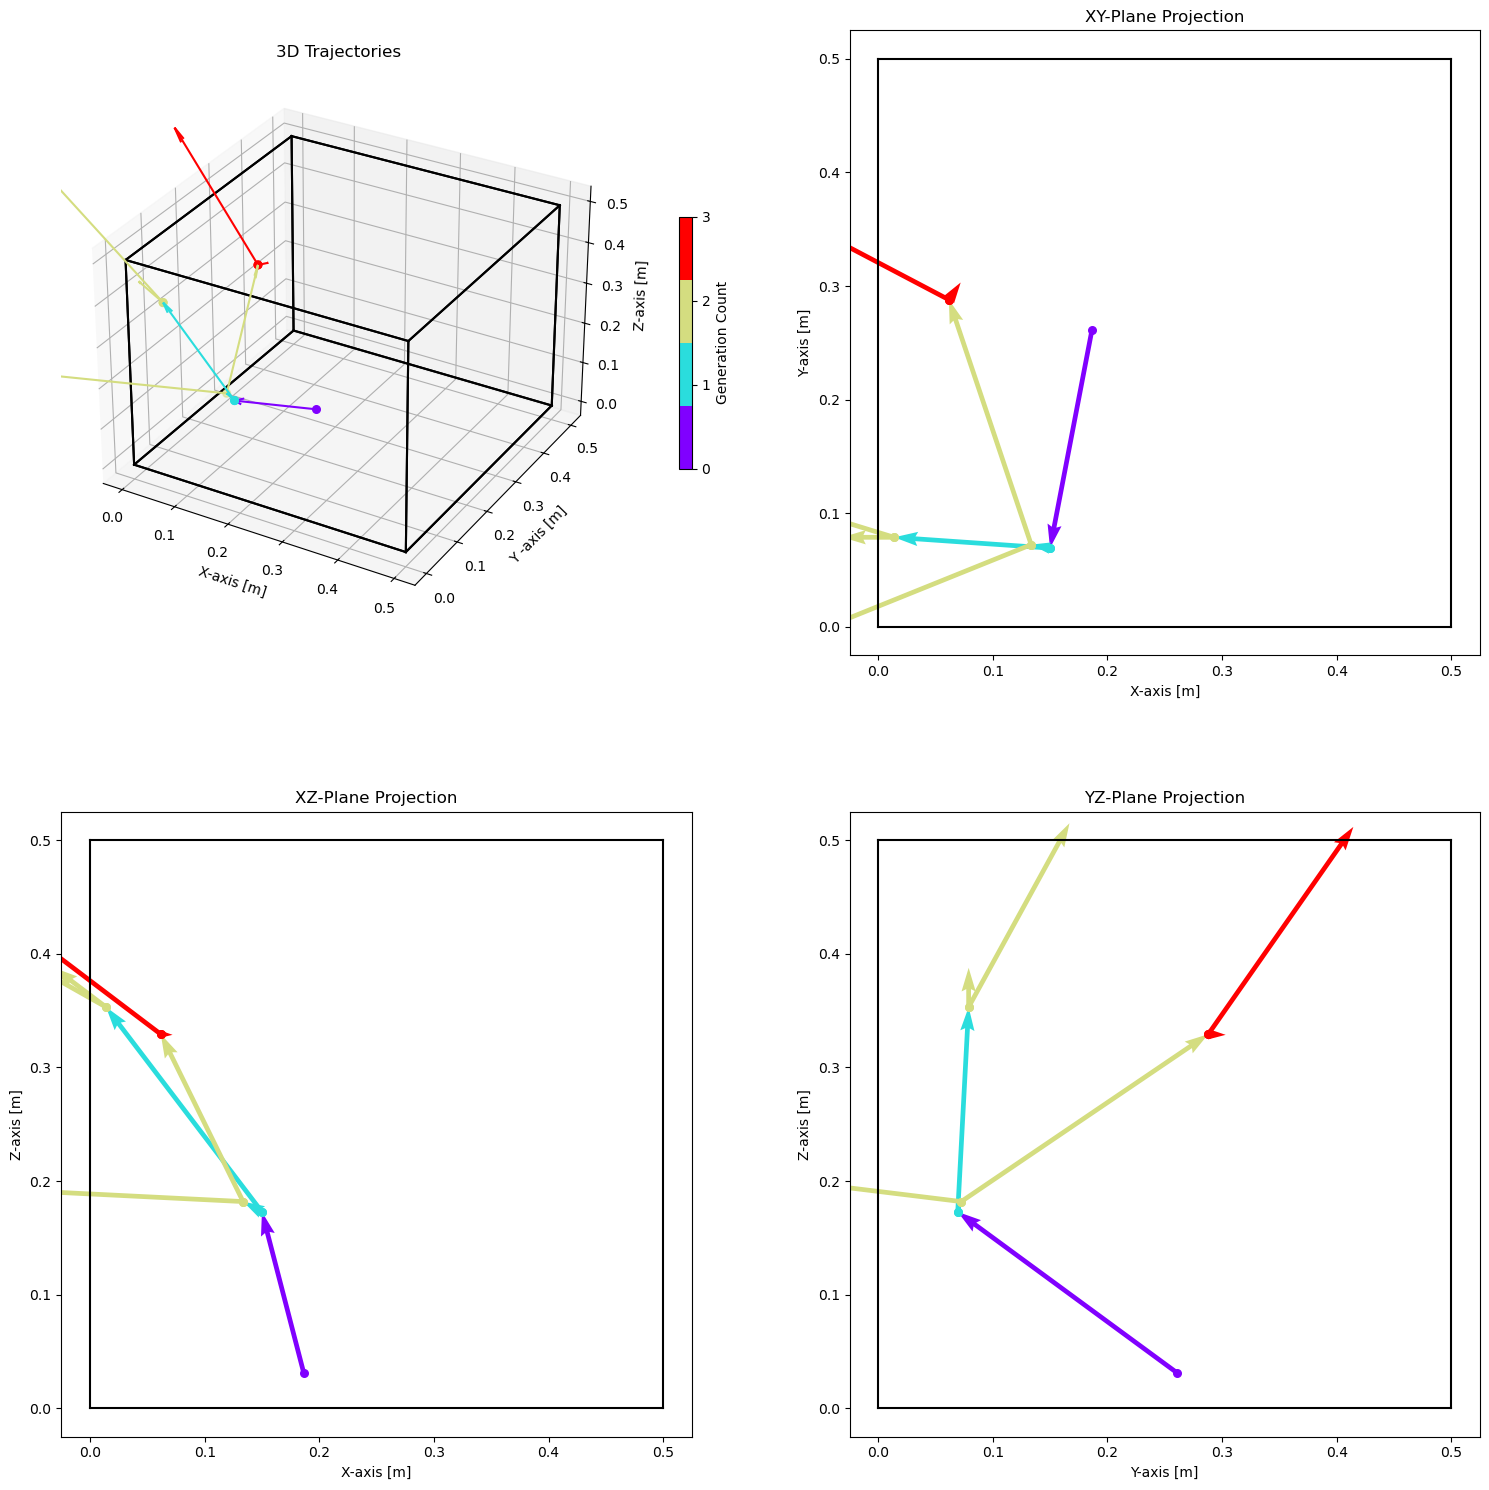

Completed 1 simulations with 1 initial neutrons per simulation over 4 generations.
Execution time: 1.2737 seconds


In [159]:
# Number of starting protons N0
N0 = 1

# Number of trials to run
mtrials = 1

# Max generations
max_gen = 4

# Fermi's best guess of the mean free path
# based on the neutron cross section in U235
mean_free_path = 0.15 # m

# Number of new neutrons per fission event
neutron_multiplicity = 2

# Length for shapes with length parameter
length = 0.5

# Volume for shapes with volume parameter
volume = length**3

# Purity
purity = 1

# Run test on "cube" model with neutron_multiplicity = 2.4355
start_time = time.time()

# Uranium-235 Sample Shape
trajectory_test = "cube"

# Uranium-235 Sample Parameters
trajectory_test_param = {"dimensions":{"length": length}}

# Instantiate and run trials for Uranium235_Fission_Model
trajectory_test_model = Uranium235_Fission_Model(N0, mtrials, trajectory_test, trajectory_test_param, purity, neutron_multiplicity, mean_free_path, max_gen)
trajectory_test_model.plot_trajectories()

end_time = time.time()
print(f"Completed {mtrials} simulations with {N0} initial neutrons per simulation over {max_gen} generations.")
print(f"Execution time: {end_time - start_time:.4f} seconds")

#### Analysis of Neutron Trajectory Test

From the trajectory testing we observe that the model is behaving as expected with respect to neutron trajectories and removal from system upon leaving the sample boundary. We observe that the initial neutron (purple) travels along it's trajectory to its new position, before undergoing fission and producing two new generation 1 neutrons (teal); these then generate new random trajectories to travel to their next position. One travels much further than the other which makes sense given the distance is produced through an exponential distribution, however this is only generating two samples. The generation 1 neutrons travel to their final position before creating generation 2 fission products (yellow), which provide us the opportunity to verify neutron removal from the system; one third generation neutron remains within the sample while the other three exit. We observe that the one generation 3 neutron that remains within the sample generates two new fission neutrons (red), while the neutrons that exits the sample generate no further fission products or trajectories. This final generation then generates its trajectories and travels them, with two of them remaining within the sample and two exiting. This was the final generation observed however we note that at this point we have confirmed all of the requisite behaviours we set out to observe.

We note that there were some trade-offs and restructuring of the methods in order to verify that the trajectory behaviour was working as intended. The main model methods next_gen() and captured() utilize Monte Carlo methods to generate the neutrons per fission event using a Poisson distribution with a mean set to the neutron multiplicity of the model, however this method did not fit well with such a small initial sample of neutrons; as such the method next_gen_trajectories() and captured_trajectories() were restructured to guarantee two neutrons per fission event in order to better illustrate the neutron trajectory over a small number of generations. The method next_gen_trajectories() was also changed such that its return values were lists of neutron position, directions, and number of neutrons per generation rather than the $k$ factor per generation, such that we had the requisite information to produce our trajectory plots. However other than these changes, the position and trajectory functionalit was left as is such that these refactored methods still possess (and are able to validate) the trajectory behaviour of the methods used in the phase-space analysis.